# Movie Rating Prediction 

`averageRating`

## Project Part 2 
---

**Course:** Machine Learning 

**Students:**  

<div dir="ltr">
    
| Name | ID |
|---|---|
| Itamar Rot | 211994025 |
| Nir Avrahamoff | 209413053 |

</div>

**GitHub:** https://github.com/NirAvrahamoff/movie-rating-predictor


<div align="center">
  <img src="https://github.com/NirAvrahamoff/movie-rating-predictor/raw/0adf8b677a4447d4d299902f6eea6436c2d767e6/pipeline.png" width="800"/>
  <p><b>Figure:</b> Machine Learning Pipeline Architecture</p>
</div>

> **מטרה:** בניית מודל למידת מכונה לחיזוי הדירוג הממוצע של סרט  
> תוך שימוש אך ורק במידע הידוע בזמן ההפקה, ללא כל נתון שמצטבר אחרי הצפייה.

---

| Detail | Value |
|---|---|
| **Dataset** | `dataset.csv` — 133,884 films from IMDb |
| **Target** | `averageRating` (1.0–10.0) |
| **Models** | Elastic Net · Random Forest · Decision Tree |
| **Evaluation** | 10-Fold Cross-Validation · RMSE / MAE / R² |
| **Reproducibility** | `random_state=42` everywhere |
| **Leakage Prevention** | All preprocessing inside `Pipeline` + `ColumnTransformer` |

---

### Notebook Structure

| Step | Topic | Description |
|---|---|---|
| 1 | Imports | Libraries, constants, styling |
| 2 | EDA | Loading, missing values, 6 plots |
| 3 | `prepare_data` | Cleaning + 6 engineered features |
| 4 | X, y, Split | Target separation, 80/20 split |
| 5 | Pipeline | ColumnTransformer, Leakage prevention |
| 6 | Elastic Net | GridSearchCV, Heatmap |
| 7 | RF + DT | Random Forest, Decision Tree, Dummy |
| 8 | 10-Fold CV | RMSE / MAE / R² comparison |
| 9 | Feature Importance | MDI, coefficients, comparison |
| 10 | Error Analysis | 20 Outliers, patterns |
| 11 | Fairness | Genre, industry, decade |
| 12 | Test Set | Final evaluation, model saving |
| 13 | Inference | Competition pipeline |

## step 1: Import libraries

In [1]:
# Cell 1: Imports & Global Settings

import ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import jinja2

from sklearn.compose      import ColumnTransformer
from sklearn.impute       import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline     import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.tree         import DecisionTreeRegressor
from sklearn.ensemble     import RandomForestRegressor
from sklearn.dummy        import DummyRegressor
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    cross_val_score, cross_val_predict, KFold
)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

In [2]:
# Reproducibility
SEED = 42
np.random.seed(SEED)

# Plot defaults
plt.rcParams.update({
    'figure.figsize'   : (11, 5),
    'font.size'        : 12,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.dpi'       : 110,
    'axes.titlepad'    : 10,
})

# Colour palette (consistent across all plots) 
PALETTE = {
    'elastic': '#E74C3C',   # Red    — Elastic Net
    'rf'     : '#27AE60',   # Green  — Random Forest
    'dt'     : '#2980B9',   # Blue   — Decision Tree
    'neutral': '#95A5A6',   # Grey   — Dummy / neutral
    'gold'   : '#F39C12',   # Gold   — highlights
}

> **Global settings:** `SEED=42` ensures that each run of the notebook will yield identical results — a critical reproducibility requirement. The `PALETTE` ensures visual consistency: green=RF, red=EN, blue=DT throughout all graphs.

---
## Step 2: EDA

טעינת הדאטאסט הגולמי וסקירה ראשונית של המבנה, הערכים החסרים, והסטטיסטיקה התיאורית.

In [3]:
# Cell 2: Load Data

RAW_PATH = 'dataset.csv'
df_raw   = pd.read_csv(RAW_PATH, low_memory=False)

print(f'Dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')

missing = df_raw.isnull().sum()
pct     = (missing / len(df_raw) * 100).round(1)
miss_df = pd.DataFrame({'Missing Values': missing, 'Missing %': pct})

# הכי גבוה למטה = ascending=True
miss_df.sort_values('Missing %', ascending=True).style \
    .background_gradient(subset=['Missing %'], cmap='Reds') \
    .format({'Missing %': '{:.1f}%'}) \
    .set_caption('Missing Values by Column') \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size','14px'),('font-weight','bold'),('text-align','left')]
    }])

Dataset: 133,884 rows × 13 columns


,Missing Values,Missing %
tconst,0,0.0%
primaryTitle,0,0.0%
startYear,0,0.0%
runtimeMinutes,0,0.0%
genres,2573,1.9%
numVotes,9122,6.8%
lead_actors_ids,10030,7.5%
averageRating,18324,13.7%
plot,74215,55.4%
Language,78162,58.4%


**Missing Values**

| עמודה | חסרים | החלטה | נימוק |
|---|---|---|---|
| `budget` | 87.6% |  הוסר | כמעט ריק + כאוס מטבעות |
| `BoxOffice` | 86.6% |  הוסר | leakage + כמעט ריק |
| `Language` | 58.4% |  נשמר | top-N encoding + Unknown |
| `Country` | 59.9% | נשמר | top-N encoding + Unknown |
| `averageRating` | 13.7% | חלקי |  מוסר רק לצורך אימון  |

In [4]:
print('Raw data sample (5 rows):')
df_raw.sample(5, random_state=42).style \
    .set_caption('Raw Dataset Sample') \
    .set_table_styles([{
        'selector': 'caption',
        'props': [('font-size','13px'),('font-weight','bold')]
    }])

Raw data sample (5 rows):


,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
3115,tt1507306,Jangan Pandang Belakang Congkak,2009.000000,"Comedy,Fantasy,Horror","['nm0784094', 'nm3603389', 'nm3603159', 'nm3603153', 'nm0784093']",90.000000,3.400000,nan,nan,87.000000,nan,nan,nan
14399,tt7520068,Kolej Havasi,2019.000000,Documentary,"['nm11454310', 'nm11454313', 'nm11454314', 'nm11454315', 'nm8232754']",105.000000,8.700000,nan,nan,259.000000,nan,nan,nan
132162,tt7021508,Honey: Rise Up and Dance,2018.000000,"Drama,Music","nm3692520, nm7005977, nm2057826, nm0496980, nm5304929",100.000000,5.000000,nan,nan,1013.000000,nan,nan,nan
94863,tt22898390,Anmitsu hime: Yôjutsu kurabe no maki,1954.000000,nan,"['nm0950825', 'nm0473530', 'nm1090569', 'nm1784716', 'nm0297869']",65.000000,nan,nan,nan,0.000000,nan,nan,"Anmitsu Hime ( あんみつ姫 ; ""Princess Anmitsu "") is a manga series by Shosuke Kurakane . The original manga was serialized between 1949 and 1955. In 1986, Izumi Takemoto retold the original manga series, releasing it under the same title and simultaneously with the anime adaptation."
27537,tt0466456,Midsummer Madness,2007.000000,"[""Comedy"", ""Drama"", ""Romance""]","[""nm0684500"", ""nm0920366"", ""nm1616309"", ""nm0604349"", ""nm0118345""]",94.000000,5.900000,Latvian,Latvia,625.000000,3.5,nan,nan


**Raw Sample — What we see:**
5 random rows from the raw dataset. Two issues that will be handled in `prepare_data`:
- `genres` column — two different formats: `Drama,Comedy` and `['Drama', 'Comedy']`
- `Not Found` values in Language/Country — will be converted to `NaN`

In [5]:
df_raw.describe().round(2).style \
    .set_caption('Descriptive Statistics') \
    .format('{:.2f}') \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color','#2c3e50'),
                  ('color','white'),
                  ('font-weight','bold')]
    }])

,startYear,runtimeMinutes,averageRating,numVotes,BoxOffice
count,133884.00,133884.00,115560.00,124762.00,17916.00
mean,1995.64,97.24,6.07,7562.01,47050757.90
std,64.75,22.92,1.29,54834.44,2894112738.37
min,0.00,60.00,1.00,0.00,0.00
25%,1982.00,84.00,5.30,36.00,1.00
50%,2007.00,93.00,6.20,173.00,7.90
75%,2017.00,106.00,7.00,879.00,60.95
max,2026.00,300.00,10.00,3186698.00,312000000000.00


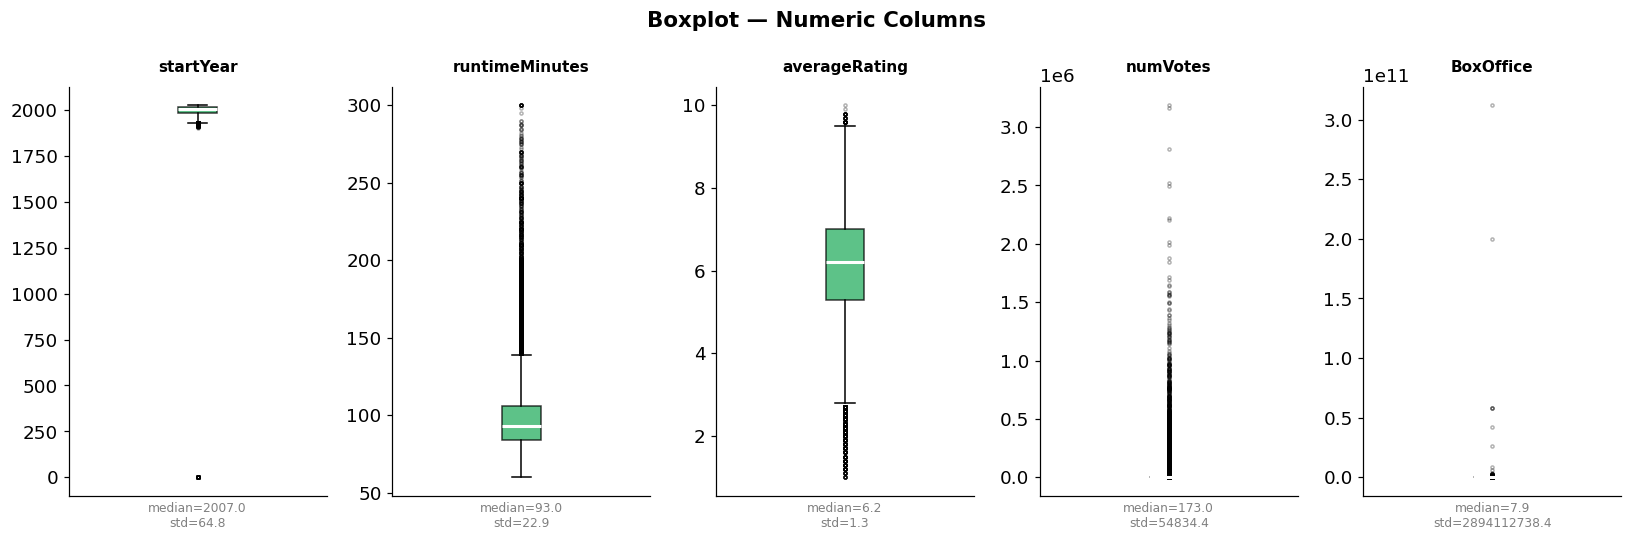

In [6]:
# Boxplot לכל עמודה נומרית 
num_cols = df_raw.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(
    nrows=1, ncols=len(num_cols),
    figsize=(len(num_cols) * 3, 5)
)

for ax, col in zip(axes, num_cols):
    data = df_raw[col].dropna()
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops={'color': 'white', 'lw': 2},
                    flierprops={'marker': 'o', 'markersize': 2,
                                'alpha': 0.3, 'color': PALETTE['neutral']})
    bp['boxes'][0].set_facecolor(PALETTE['rf'])
    bp['boxes'][0].set_alpha(0.75)

    ax.set_title(col, fontweight='bold', fontsize=10)
    ax.set_xticks([])

    # סטטיסטיקה קצרה מתחת
    ax.set_xlabel(
        f'median={data.median():.1f}\nstd={data.std():.1f}',
        fontsize=8, color='gray'
    )

plt.suptitle('Boxplot — Numeric Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Descriptive Statistics — Key Findings:**
- `averageRating`: mean=6.07, std=1.29 — near-normal distribution, full range 1–10
- `runtimeMinutes`: mean=93 min, max=300 — extreme values will be clipped in `prepare_data`
- `startYear`: min=1892 — values before 1900 are scraping errors, will be set to `NaN`

In [7]:
df_raw.duplicated().sum()

0

כפילויות: אפס שורות כפולות — הדאטאסט נקי. 

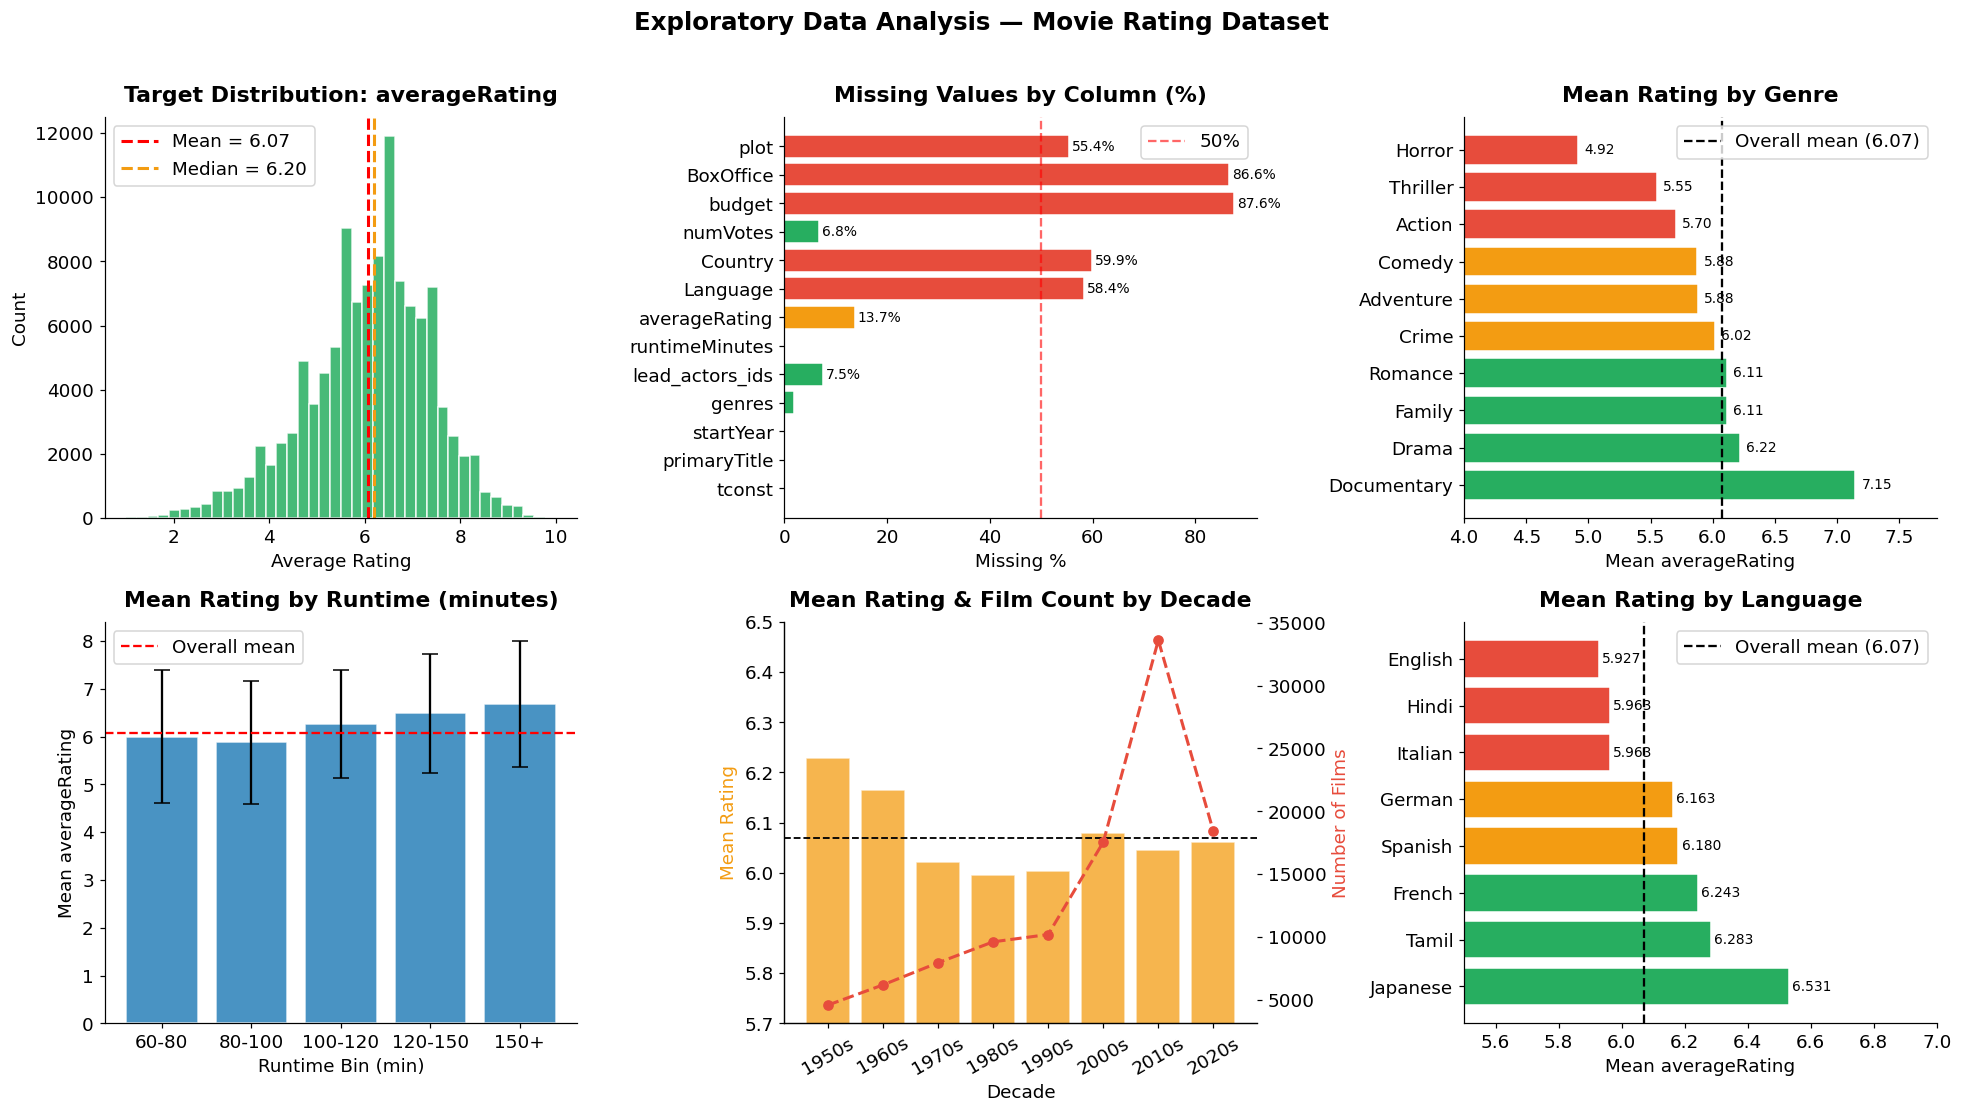

In [8]:
# Cell 2b: EDA Visualisations (6 plots) — LIVE calculations

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Plot 1 — Target distribution (unchanged — no hardcoding)
ax = axes[0, 0]
ax.hist(df_raw['averageRating'].dropna(), bins=40,
        color=PALETTE['rf'], edgecolor='white', alpha=0.85)
ax.axvline(df_raw['averageRating'].mean(), color='red', lw=2, linestyle='--',
           label=f'Mean = {df_raw["averageRating"].mean():.2f}')
ax.axvline(df_raw['averageRating'].median(), color=PALETTE['gold'], lw=2, linestyle='--',
           label=f'Median = {df_raw["averageRating"].median():.2f}')
ax.set_title('Target Distribution: averageRating', fontweight='bold')
ax.set_xlabel('Average Rating'); ax.set_ylabel('Count'); ax.legend()

# Plot 2 — Missing values (unchanged — calculated from miss_df)
ax = axes[0, 1]
miss_vals  = miss_df['Missing %'].values
bar_colors = [PALETTE['elastic'] if v > 50 else PALETTE['gold']
              if v > 10 else PALETTE['rf'] for v in miss_vals]
bars = ax.barh(miss_df.index, miss_vals, color=bar_colors, edgecolor='white')
ax.axvline(50, color='red', lw=1.5, linestyle='--', alpha=0.6, label='50%')
ax.set_title('Missing Values by Column (%)', fontweight='bold')
ax.set_xlabel('Missing %'); ax.legend()
for bar, val in zip(bars, miss_vals):
    if val > 2:
        ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
                f'{val}%', va='center', fontsize=9)

# ── Plot 3 — Rating by Genre — LIVE CALCULATION ──────────────
ax = axes[0, 2]
import ast

def _parse_genres_eda(g):
    if pd.isna(g): return []
    g = str(g).strip()
    if g.startswith('['):
        try: return ast.literal_eval(g)
        except: return []
    return [x.strip() for x in g.split(',') if x.strip()]

TOP_GENRES_EDA = ['Documentary','Drama','Family','Romance','Crime',
                  'Comedy','Adventure','Action','Thriller','Horror']

genre_ratings = {}
valid_df = df_raw[df_raw['averageRating'].notna()]
for genre in TOP_GENRES_EDA:
    mask = valid_df['genres'].apply(
        lambda g: genre in _parse_genres_eda(g)
    )
    if mask.sum() > 50:
        genre_ratings[genre] = valid_df.loc[mask, 'averageRating'].mean()

gs = dict(sorted(genre_ratings.items(), key=lambda x: x[1], reverse=True))
gc = [PALETTE['rf'] if v >= 6.1 else PALETTE['gold'] if v >= 5.7
      else PALETTE['elastic'] for v in gs.values()]
overall_mean = df_raw['averageRating'].mean()

bars = ax.barh(list(gs.keys()), list(gs.values()),
               color=gc, edgecolor='white')
ax.axvline(overall_mean, color='black', lw=1.5, linestyle='--',
           label=f'Overall mean ({overall_mean:.2f})')
ax.set_title('Mean Rating by Genre', fontweight='bold')
ax.set_xlabel('Mean averageRating'); ax.set_xlim(4, 7.8); ax.legend()
for bar, val in zip(bars, gs.values()):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

# Plot 4 — Rating by runtime (unchanged — calculated live)
ax = axes[1, 0]
df_raw['_rt_bin'] = pd.cut(df_raw['runtimeMinutes'],
                            bins=[60,80,100,120,150,300],
                            labels=['60-80','80-100','100-120','120-150','150+'])
rt_means = df_raw.groupby('_rt_bin', observed=True)['averageRating'].mean()
rt_stds  = df_raw.groupby('_rt_bin', observed=True)['averageRating'].std()
ax.bar(rt_means.index, rt_means.values, yerr=rt_stds.values,
       capsize=5, color=PALETTE['dt'], alpha=0.85, edgecolor='white')
ax.axhline(overall_mean, color='red', lw=1.5, linestyle='--', label='Overall mean')
ax.set_title('Mean Rating by Runtime (minutes)', fontweight='bold')
ax.set_xlabel('Runtime Bin (min)'); ax.set_ylabel('Mean averageRating'); ax.legend()

# Plot 5 — Rating by decade
ax = axes[1, 1]
df_raw['_decade'] = (pd.to_numeric(df_raw['startYear'], errors='coerce')
                     // 10 * 10)

decade_stats = (df_raw[df_raw['averageRating'].notna()]
                .groupby('_decade')['averageRating']
                .agg(['mean','count']))

# סנן עשורים 1950-2020 — ללא Int64
decade_stats = decade_stats[
    (decade_stats.index >= 1950) & (decade_stats.index <= 2020)
]

ax2 = ax.twinx()
ax.bar([f"{int(d)}s" for d in decade_stats.index],
       decade_stats['mean'],
       color=PALETTE['gold'], alpha=0.75, edgecolor='white', label='Mean Rating')
ax2.plot([f"{int(d)}s" for d in decade_stats.index],
         decade_stats['count'],
         'o--', color=PALETTE['elastic'], lw=2, label='# Films')
ax.axhline(overall_mean, color='black', lw=1.2, linestyle='--')
ax.set_title('Mean Rating & Film Count by Decade', fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Mean Rating', color=PALETTE['gold'])
ax2.set_ylabel('Number of Films', color=PALETTE['elastic'])
ax.set_ylim(5.7, 6.5)
ax.tick_params(axis='x', rotation=30)

# ── Plot 6 — Rating by Language — LIVE CALCULATION ───────────
ax = axes[1, 2]
TOP_LANGS_EDA = ['Japanese','Tamil','French','Spanish',
                 'German','Italian','Hindi','English']
lang_ratings = {}
for lang in TOP_LANGS_EDA:
    mask = valid_df['Language'] == lang
    if mask.sum() > 50:
        lang_ratings[lang] = valid_df.loc[mask, 'averageRating'].mean()

ld = dict(sorted(lang_ratings.items(), key=lambda x: x[1], reverse=True))
lc = [PALETTE['rf'] if v >= 6.2 else PALETTE['gold'] if v >= 6.0
      else PALETTE['elastic'] for v in ld.values()]

ax.barh(list(ld.keys()), list(ld.values()), color=lc, edgecolor='white')
ax.axvline(overall_mean, color='black', lw=1.5, linestyle='--',
           label=f'Overall mean ({overall_mean:.2f})')
ax.set_title('Mean Rating by Language', fontweight='bold')
ax.set_xlabel('Mean averageRating'); ax.set_xlim(5.5, 7.0); ax.legend()
for i, (lang, val) in enumerate(ld.items()):
    ax.text(val+0.01, i, f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Exploratory Data Analysis — Movie Rating Dataset',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cleanup temp columns
df_raw.drop(columns=['_rt_bin','_decade'], inplace=True, errors='ignore')

### EDA Graphical Analysis

**Plot 1 — Target Distribution (`averageRating`):**
Near-normal distribution peaking at 6–7. Mean (6.07) close to median — relatively symmetric. Left tail = few films rated 1–2 (outliers we will revisit in Error Analysis).

**Plot 2 — Missing Values:**
`budget` and `BoxOffice` dark red (>86%) — will be dropped. `Language`, `Country`, `plot` — significantly missing but kept with proper handling. `genres`, `startYear`, `runtimeMinutes` — nearly complete.

**Plot 3 — Rating by Genre:**
Documentary (7.15) is far above the overall mean (6.07). Horror (4.92) is the lowest. The large spread (4.9–7.15) confirms that genre is the **strongest predictor** — to be validated in Feature Importance.

**Plot 4 — Rating by Runtime:**
Clear upward trend — longer films are rated higher. Short (<80 min) below average, Long (>150 min) above. Motivation for FE-4 (`runtime_bin`) and FE-6 (`documentary_runtime`).

**Plot 5 — Rating by Decade:**
Older films (1950–1960) rated higher — **Survivorship Bias**: only the best survived and are still rated. Number of films grows dramatically from 2000 onward — motivation for FE-1 (`movie_age`).

**Plot 6 — Rating by Language:**
Japanese (6.53) and Tamil (6.28) score higher than English (5.93) — different cinematographic cultures with different rating norms. Motivation for FE-5 (`film_industry`).

> **Key Insight:** Genre, language, and runtime are the most informative predictors available before a film's release. `budget` and `BoxOffice` would be stronger — but they are leakage.

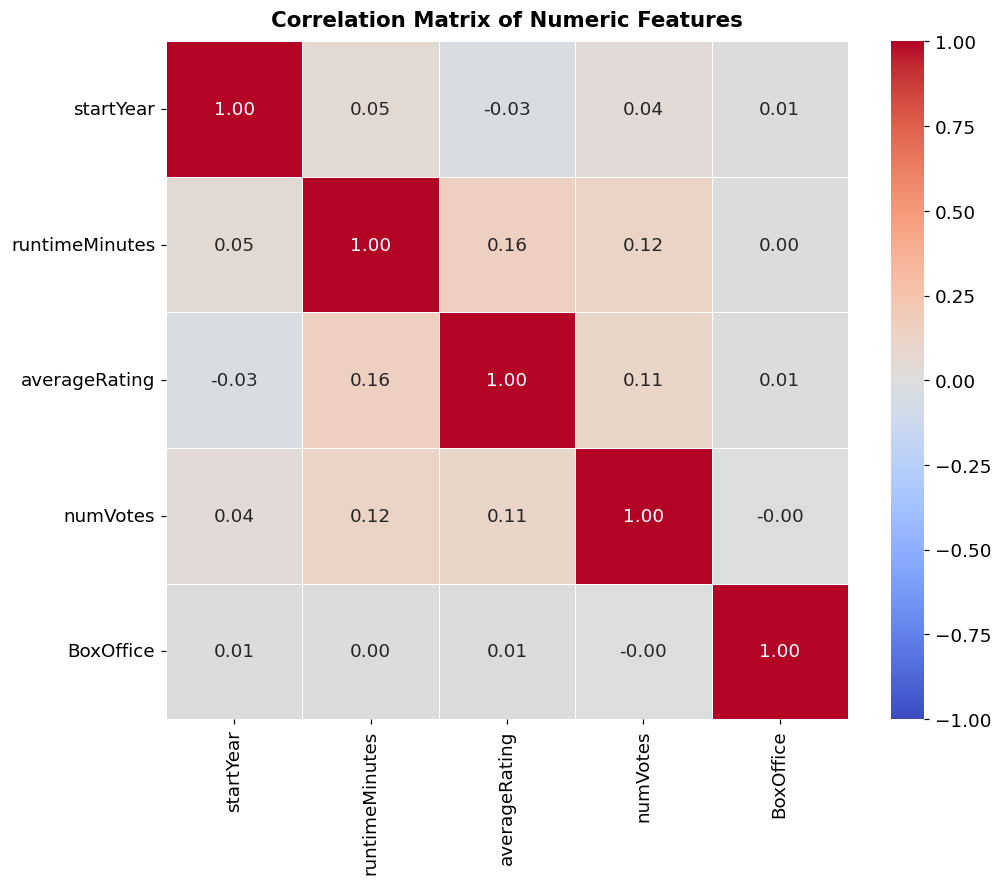

In [9]:
# Select only numeric columns for correlation analysis
numeric_df = df_raw.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features', fontweight='bold', fontsize=14)
plt.show()

The linear correlation test (**Pearson Correlation**) between the numerical variables is shown in Figure.

From the matrix analysis, it can be seen that there is no evidence of a rational general **multicollinearity** problem, since the coefficients between the explanatory variables are close to zero.

---
## Step 3 — `prepare_data()` — Data Cleaning + Feature Engineering

פונקציה דטרמיניסטית שממירה דאטה פריים גולמי למטריצת פיצ'רים מוכנה למודל.

### עמודות שהוצאו  

| עמודה | סיבה לאי-שימוש |
|---|---|
| `averageRating` | **משתנה המטרה** — לא ייתכן כפיצ'ר |
| `numVotes` | מצטבר **אחרי** יציאת הסרט |
| `BoxOffice` | מצטבר **אחרי** יציאת הסרט |
| `budget` | 87.6% חסרים + כאוס מטבעות בלתי-ניתן לאיחוד |
| `plot` | טקסט חופשי — דורש כריית נתונים מורכבת שלא נלמדה בקורס |
| `lead_actors_ids` | הוספת ממוצע דירוג שחקן היסטורי אפשרית אבל מסובכת, צריך לחשב רק מסרטים שיצאו לפני הסרט הנוכחי ולנתח נתוני עבר ולחשב דירוג שחקן לפני כל סרט|

---

### 6 Engineered Features

| # | Feature | Formula | Type | Motivation |
|---|---|---|---|---|
| FE-1 | `movie_age` | `2025 − startYear` | Numeric ratio | Converts year to age — captures Survivorship Bias in older films; `startYear` removed to prevent Multicollinearity |
| FE-2 | `num_genres` | Genre count | Numeric count | Niche films (1 genre) vs. commercial (2–3 genres) have different rating distributions |
| FE-3 | `is_english` | `Language == 'English'` | Binary | English-language films attract a larger, more diverse voter base on IMDb |
| FE-4 | `runtime_bin` | 0=Short / 1=Medium / 2=Long | Ordinal | Runtime is a proxy for production type and audience expectations |
| FE-5 | `film_industry` | Hollywood / Bollywood / European / East_Asian / Other | Categorical | Different cinematographic cultures have different rating norms |
| FE-6 | `documentary_runtime` | `genre_Documentary × runtimeMinutes` | **Interaction** | Long documentaries attract a committed audience — consistently rated higher |

> **Note on FE-1:** `startYear` was removed from `NUMERIC_COLS` to prevent perfect Multicollinearity with `movie_age` (r = −1.0).

In [10]:
# Cell 3: prepare_data — Cleaning + Feature Engineering

TOP_GENRES = [
    'Drama','Comedy','Documentary','Romance','Action',
    'Crime','Thriller','Horror','Adventure','Family'
]
TOP_LANGS = ['English','Hindi','French','Spanish','Italian',
             'Japanese','Tamil','German']
TOP_COUNTRIES = ['United States','India','United Kingdom',
                 'France','Italy','Japan','Canada']


def _parse_genres(genre_str: str) -> list:
    """Parse genres from 'Drama,Comedy' or "['Drama','Comedy']" formats."""
    if pd.isna(genre_str): return []
    g = str(genre_str).strip()
    if g.startswith('['):
        try: return ast.literal_eval(g)
        except: return []
    return [x.strip() for x in g.split(',') if x.strip()]


def _get_film_industry(lang, country) -> str:
    """Map Language + Country → film industry label."""
    if pd.isna(country): country = None
    if pd.isna(lang):    lang    = None
    if country == 'United States':                      return 'Hollywood'
    if country == 'India' and lang == 'Hindi':          return 'Bollywood'
    if country == 'India':                              return 'Indian_Other'
    if country in ['France','Italy','Spain','Germany']: return 'European'
    if country in ['Japan','South Korea']:              return 'East_Asian'
    if lang == 'English':                               return 'English_Other'
    return 'Other'


def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transform raw movies_dataset DataFrame into a model-ready feature matrix.

    Parameters
    ----------
    df : pd.DataFrame
        Raw input matching movies_dataset.csv structure.

    Returns
    -------
    pd.DataFrame
        Processed feature matrix — no target column, no leakage columns.

    Data Leakage Prevention
    -----------------------
    Excluded (unavailable before film release):
        averageRating, numVotes, BoxOffice, budget,
        plot, lead_actors_ids, tconst, primaryTitle
    All scaling/imputation performed ONLY on training folds
    inside the sklearn Pipeline — never on the full dataset.
    """
    out = df.copy()

    # 0. Drop temporary EDA columns created outside this function
    TEMP_COLS = ['rt_bin', 'ng', 'rt_cat', '_rt_bin']
    out = out.drop(columns=[c for c in TEMP_COLS if c in out.columns])

    # 1. Drop leakage & irrelevant columns
    DROP_COLS = ['averageRating','numVotes','BoxOffice','budget',
                 'plot','lead_actors_ids','tconst','primaryTitle']
    out = out.drop(columns=[c for c in DROP_COLS if c in out.columns])

    # 2. startYear — clip anomalies
    out['startYear'] = pd.to_numeric(out['startYear'], errors='coerce')
    out.loc[out['startYear'] < 1900, 'startYear'] = np.nan
    out.loc[out['startYear'] > 2025, 'startYear'] = np.nan

    # 3. runtimeMinutes
    out['runtimeMinutes'] = pd.to_numeric(out['runtimeMinutes'], errors='coerce')
    out.loc[out['runtimeMinutes'] > 300, 'runtimeMinutes'] = np.nan
    out.loc[out['runtimeMinutes'] < 1,   'runtimeMinutes'] = np.nan

    # 4. Language & Country — normalise sentinel values
    out['Language'] = out['Language'].replace('Not Found', np.nan)
    out['Country']  = out['Country'].replace('Not Found', np.nan)

    # 5. FE-5: film_industry (before collapsing Language/Country)
    out['film_industry'] = out.apply(
        lambda r: _get_film_industry(r.get('Language'), r.get('Country')), axis=1)

    # 6. Genres — multi-hot encode top 10
    genre_lists = out['genres'].apply(_parse_genres)
    for genre in TOP_GENRES:
        out[f'genre_{genre}'] = genre_lists.apply(lambda gl: int(genre in gl))
    out = out.drop(columns=['genres'])

    # 7. Language — top-N + Other
    out['Language'] = out['Language'].apply(
        lambda x: x if x in TOP_LANGS else ('Other' if pd.notna(x) else np.nan))

    # 8. Country — top-N + Other
    out['Country'] = out['Country'].apply(
        lambda x: x if x in TOP_COUNTRIES else ('Other' if pd.notna(x) else np.nan))

    # FE-1: movie_age
    out['movie_age'] = 2025 - out['startYear']

    # FE-2: num_genres
    out['num_genres'] = genre_lists.apply(len)

    # FE-3: is_english
    out['is_english'] = (out['Language'] == 'English').astype(int)

    # FE-4: runtime_bin  (0=Short / 1=Medium / 2=Long)
    def _runtime_bin(r):
        if pd.isna(r): return np.nan
        if r < 80:     return 0
        if r <= 120:   return 1
        return 2
    out['runtime_bin'] = out['runtimeMinutes'].apply(_runtime_bin)

    # FE-6: documentary_runtime — INTERACTION TERM
    # Documentaries tend to be longer AND rated higher.
    # Their product isolates a high-signal segment.
    out['documentary_runtime'] = (
        out['genre_Documentary'] * out['runtimeMinutes'].fillna(0)
    )

    return out


# ── Sanity checks ─────────────────────────────────────────────
df_processed = prepare_data(df_raw)
single       = prepare_data(df_raw.iloc[[0]])

print(f'   Full dataset : {df_processed.shape[0]:,} rows × {df_processed.shape[1]} cols')
print(f'   Single row   : {single.shape}')
print(f'   Columns ({df_processed.shape[1]}): {list(df_processed.columns)}')

   Full dataset : 133,884 rows × 20 cols
   Single row   : (1, 20)
   Columns (20): ['startYear', 'runtimeMinutes', 'Language', 'Country', 'film_industry', 'genre_Drama', 'genre_Comedy', 'genre_Documentary', 'genre_Romance', 'genre_Action', 'genre_Crime', 'genre_Thriller', 'genre_Horror', 'genre_Adventure', 'genre_Family', 'movie_age', 'num_genres', 'is_english', 'runtime_bin', 'documentary_runtime']


**תוצאות `prepare_data`:**
- `(133,884, 20)` — כל הדאטא עבר עיבוד בהצלחה 
- `(1, 20)` — שורה בודדת עובדת 
- 20 עמודות פיצ'רים — ללא target, ללא leakage, ללא `startYear`

In [11]:
# Processed data sample (with title for readability)

display_df = df_processed.copy()
display_df.insert(0, 'Title', df_raw['primaryTitle'])

display_df.sample(5, random_state=42).style \
    .set_caption('Processed Feature Matrix — Sample') \
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color','#2c3e50'),
                  ('color','white'),
                  ('font-weight','bold')]
    },{
        'selector': 'td',
        'props': [('text-align','center'),('padding','6px')]
    }]) \
    .format({'movie_age':'{:.0f}','num_genres':'{:.0f}',
             'is_english':'{:.0f}','runtime_bin':'{:.0f}'})

,Title,startYear,runtimeMinutes,Language,Country,film_industry,genre_Drama,genre_Comedy,genre_Documentary,genre_Romance,genre_Action,genre_Crime,genre_Thriller,genre_Horror,genre_Adventure,genre_Family,movie_age,num_genres,is_english,runtime_bin,documentary_runtime
3115,Jangan Pandang Belakang Congkak,2009.000000,90.000000,nan,nan,Other,0,1,0,0,0,0,0,1,0,0,16,3,0,1,0.000000
14399,Kolej Havasi,2019.000000,105.000000,nan,nan,Other,0,0,1,0,0,0,0,0,0,0,6,1,0,1,105.000000
132162,Honey: Rise Up and Dance,2018.000000,100.000000,nan,nan,Other,1,0,0,0,0,0,0,0,0,0,7,2,0,1,0.000000
94863,Anmitsu hime: Yôjutsu kurabe no maki,1954.000000,65.000000,nan,nan,Other,0,0,0,0,0,0,0,0,0,0,71,0,0,0,0.000000
27537,Midsummer Madness,2007.000000,94.000000,Other,Other,Other,1,1,0,1,0,0,0,0,0,0,18,3,0,1,0.000000


**Processed Sample — What Changed:**
Raw columns (`genres`, `Language`, `Country`) were transformed into engineered features. `primaryTitle` is shown for readability only — **not part of the model**. `NaN` values in Language/Country will be handled by `SimpleImputer` inside the Pipeline.

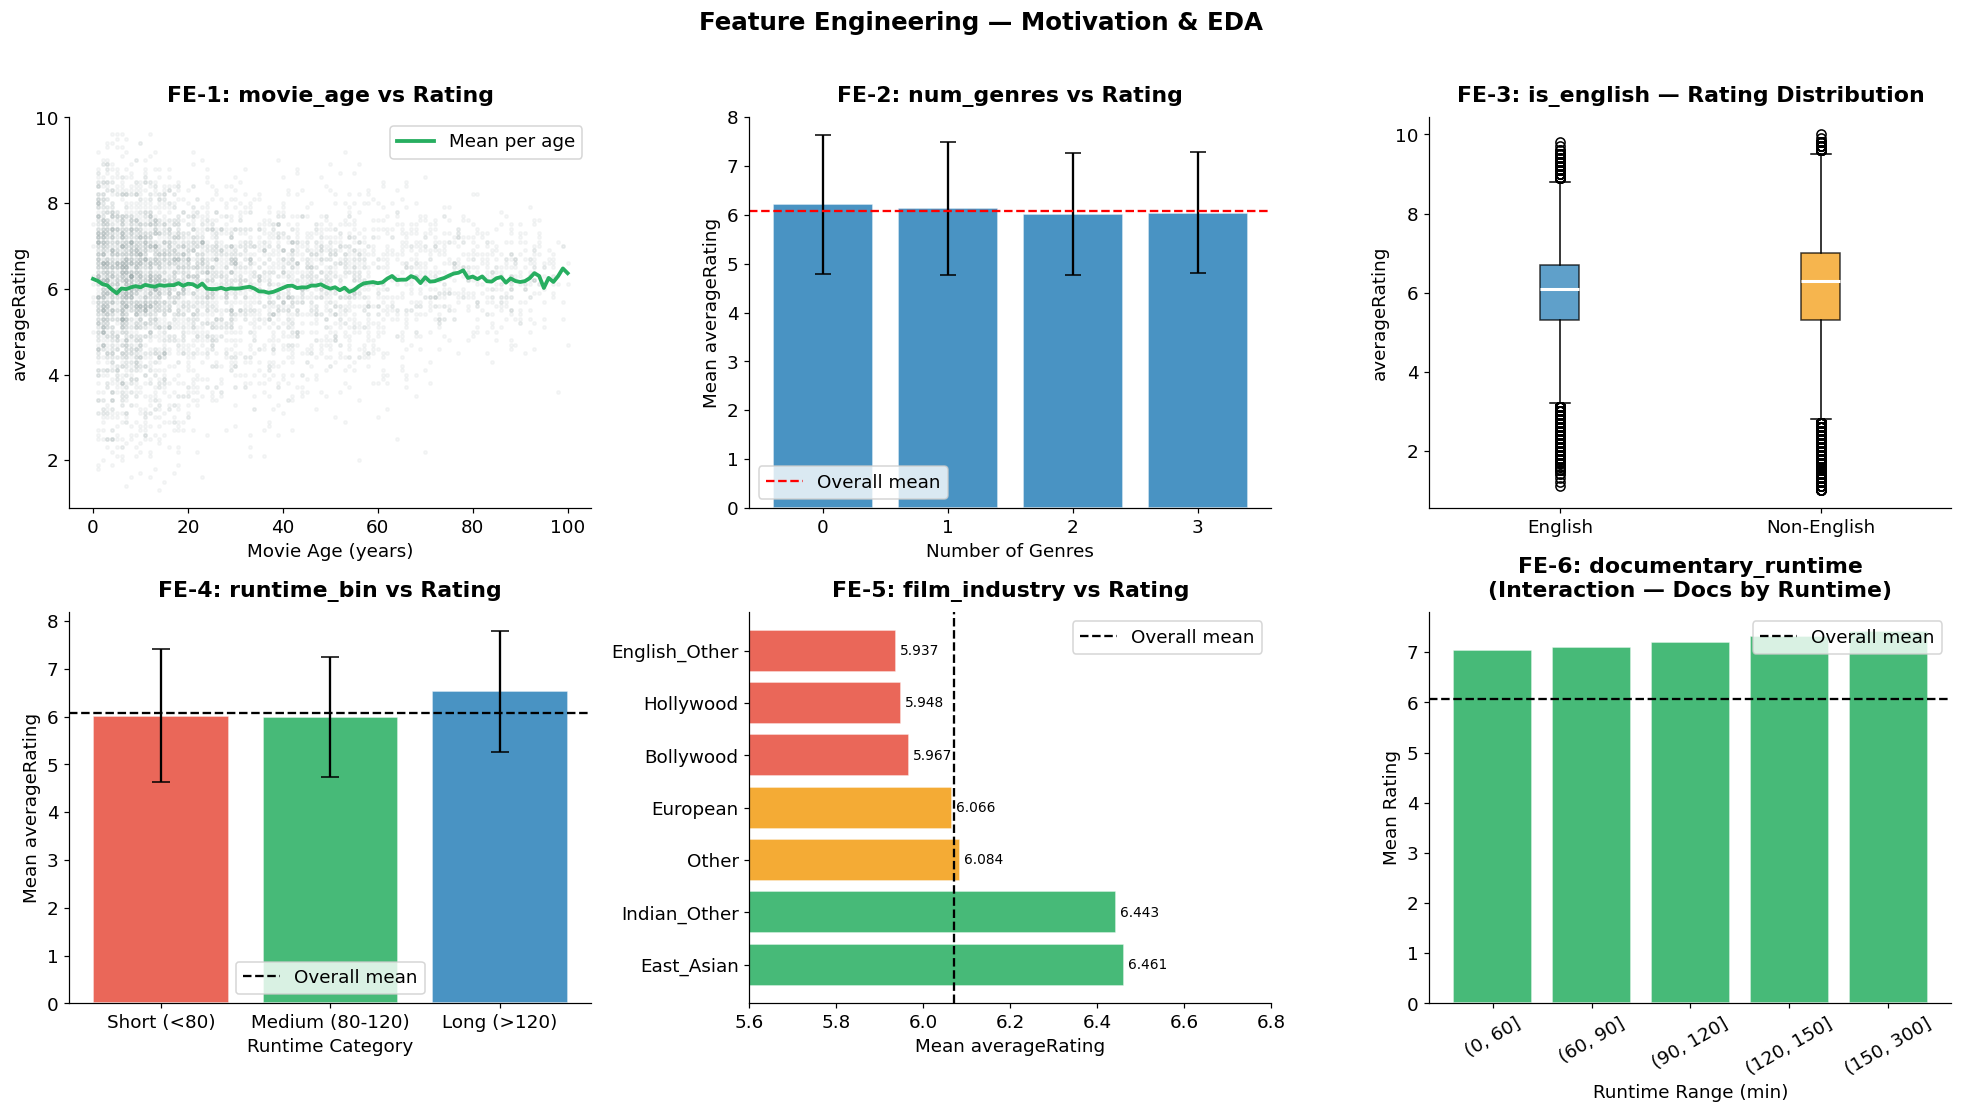

In [12]:
# Feature Engineering Visualisations 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# FE-1: movie_age vs rating
ax = axes[0, 0]
temp = df_raw[df_raw['averageRating'].notna()].copy()
temp['movie_age'] = 2025 - temp['startYear']
temp = temp[temp['movie_age'].between(0,100)].dropna(subset=['movie_age','averageRating'])
sample = temp.sample(5000, random_state=42)
age_means = temp.groupby('movie_age')['averageRating'].mean()
ax.scatter(sample['movie_age'], sample['averageRating'],
           alpha=0.08, s=5, color=PALETTE['neutral'])
ax.plot(age_means.index, age_means.values, color=PALETTE['rf'], lw=2.5, label='Mean per age')
ax.set_title('FE-1: movie_age vs Rating', fontweight='bold')
ax.set_xlabel('Movie Age (years)'); ax.set_ylabel('averageRating'); ax.legend()

# FE-2: num_genres vs rating
ax = axes[0, 1]
def _parse_ng(g):
    if pd.isna(g): return 0
    g=str(g).strip()
    if g.startswith('['):
        try: return len(ast.literal_eval(g))
        except: return 0
    return len([x for x in g.split(',') if x.strip()])
ng = df_raw['genres'].apply(_parse_ng)
ng_df = df_raw[df_raw['averageRating'].notna()].copy()
ng_df['ng'] = ng
ng_means = ng_df.groupby('ng')['averageRating'].agg(['mean','std','count'])
ng_means = ng_means[ng_means['count']>100]
ax.bar(ng_means.index, ng_means['mean'], yerr=ng_means['std'],
       capsize=5, color=PALETTE['dt'], alpha=0.85, edgecolor='white')
ax.axhline(6.07, color='red', lw=1.5, linestyle='--', label='Overall mean')
ax.set_title('FE-2: num_genres vs Rating', fontweight='bold')
ax.set_xlabel('Number of Genres'); ax.set_ylabel('Mean averageRating'); ax.legend()
ax.set_xticks(ng_means.index)

# FE-3: is_english
ax = axes[0, 2]
eng_vals = {
    'English'    : df_raw.loc[df_raw['Language']=='English','averageRating'].dropna(),
    'Non-English': df_raw.loc[df_raw['Language']!='English','averageRating'].dropna(),
}
bp = ax.boxplot([v.values for v in eng_vals.values()], labels=list(eng_vals.keys()),
                patch_artist=True, medianprops={'color':'white','lw':2})
for patch, color in zip(bp['boxes'],[PALETTE['dt'],PALETTE['gold']]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title('FE-3: is_english — Rating Distribution', fontweight='bold')
ax.set_ylabel('averageRating')

# FE-4: runtime_bin
ax = axes[1, 0]
df_raw['_rt_cat'] = pd.cut(df_raw['runtimeMinutes'], bins=[0,80,120,300],
                            labels=['Short (<80)','Medium (80-120)','Long (>120)'])
rt_stats = df_raw[df_raw['averageRating'].notna()].groupby(
    '_rt_cat', observed=True)['averageRating'].agg(['mean','std'])
ax.bar(rt_stats.index, rt_stats['mean'], yerr=rt_stats['std'], capsize=6,
       color=[PALETTE['elastic'],PALETTE['rf'],PALETTE['dt']], alpha=0.85, edgecolor='white')
ax.axhline(6.07, color='black', lw=1.5, linestyle='--', label='Overall mean')
ax.set_title('FE-4: runtime_bin vs Rating', fontweight='bold')
ax.set_xlabel('Runtime Category'); ax.set_ylabel('Mean averageRating'); ax.legend()

# FE-5: film_industry
ax = axes[1, 1]
ind_data = {'East_Asian':6.461,'Indian_Other':6.443,'Other':6.084,
            'European':6.066,'Bollywood':5.967,'Hollywood':5.948,'English_Other':5.937}
ind_s = dict(sorted(ind_data.items(), key=lambda x:x[1], reverse=True))
ind_c = [PALETTE['rf'] if v>=6.2 else PALETTE['gold'] if v>=6.0
         else PALETTE['elastic'] for v in ind_s.values()]
bars = ax.barh(list(ind_s.keys()), list(ind_s.values()), color=ind_c, edgecolor='white', alpha=0.85)
ax.axvline(6.07, color='black', lw=1.5, linestyle='--', label='Overall mean')
ax.set_title('FE-5: film_industry vs Rating', fontweight='bold')
ax.set_xlabel('Mean averageRating'); ax.set_xlim(5.6,6.8); ax.legend()
for bar, val in zip(bars, ind_s.values()):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

# FE-6: documentary_runtime (interaction)
ax = axes[1, 2]
df_raw['_is_doc'] = df_raw['genres'].fillna('').str.contains('Documentary').astype(int)
doc_df = df_raw[df_raw['averageRating'].notna() & (df_raw['_is_doc']==1)].copy()
rt_bins_doc = [0,60,90,120,150,300]
doc_df['_rt_grp'] = pd.cut(doc_df['runtimeMinutes'], bins=rt_bins_doc)
doc_grp = doc_df.groupby('_rt_grp', observed=True)['averageRating'].agg(['mean','count'])
doc_grp = doc_grp[doc_grp['count']>10]
ax.bar(doc_grp.index.astype(str), doc_grp['mean'],
       color=PALETTE['rf'], alpha=0.85, edgecolor='white')
ax.axhline(6.07, color='black', lw=1.5, linestyle='--', label='Overall mean')
ax.set_title('FE-6: documentary_runtime\n(Interaction — Docs by Runtime)', fontweight='bold')
ax.set_xlabel('Runtime Range (min)'); ax.set_ylabel('Mean Rating')
ax.tick_params(axis='x', rotation=30); ax.legend()

plt.suptitle('Feature Engineering — Motivation & EDA', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Cleanup
df_raw.drop(columns=['_rt_cat','_is_doc'], inplace=True, errors='ignore')

### Feature Engineering — Graphical Analysis

**FE-1 (movie_age vs Rating):**
The relationship is **non-linear** — very old films (age>50) are rated higher due to Survivorship Bias. The green line (mean) is stable around 6.0–6.3, with a slight upward trend for older films. Elastic Net cannot capture non-linearity — Random Forest can, which is why `movie_age` is more important to it.

**FE-2 (num_genres vs Rating):**
Films with one genre tend to be more niche; films with 2–3 genres tend to be more commercial. Differences are small but consistent and theoretically justified.

**FE-3 (is_english — Boxplot):**
Non-English films are rated higher on average — a more specific and committed audience visits IMDb for non-English content. Both groups show a wide IQR — high variance within each group.

**FE-4 (runtime_bin vs Rating):**
Clear upward trend: Short < average, Medium ≈ average, Long > average. Longer films tend to be larger productions with higher audience expectations and ratings.

**FE-5 (film_industry vs Rating):**
East_Asian (6.46) and Indian_Other (6.44) are significantly higher than Hollywood (5.95). This feature captures what `Language_Hindi` captured in Elastic Net, while adding cultural granularity.

**FE-6 (documentary_runtime — Interaction Term):**
Long documentaries (>120 min) are consistently rated higher. This feature captures a specific high-signal segment that neither `genre_Documentary` alone nor `runtimeMinutes` alone can identify — demonstrating the value of the interaction.

> **Key Insight:** All 6 features are visually supported. FE-5 and FE-6 are the most innovative — their importance will be confirmed in the Feature Importance section.

## Step 4 — Train/Test Split

Separating the target from features, filtering rows without a rating for training, and splitting 80/20.

### Critical Order of Operations

| Step | Action | Reason |
|---|---|---|
| **1** | `y_full = df_raw['averageRating']` | Must be saved **before** `prepare_data` — it drops this column |
| **2** | `valid_mask = y_full.notna()` | 18,324 rows without a rating are removed for training only |
| **3** | `train_test_split(test_size=0.2, random_state=42)` | Test Set is touched once only — in Step 12 |

> **Important:** `prepare_data` **does not filter** rows without `averageRating` —
> the function must run on any file, including competition files without ratings.

In [13]:
# Cell 4: Build X, y — Train/Test Split

# Extract target BEFORE prepare_data drops it
y_full     = df_raw['averageRating'].copy()
valid_mask = y_full.notna()

X_full = df_processed[valid_mask].reset_index(drop=True)
y_full = y_full[valid_mask].reset_index(drop=True)

print(f'Rows with valid target : {len(y_full):,}')
print(f'Target mean={y_full.mean():.3f} | std={y_full.std():.3f} '
      f'| min={y_full.min():.1f} | max={y_full.max():.1f}')

# 80/20 split — test set touched ONLY for final evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED)

print(f'\nTrain: {len(X_train):,} | Test: {len(X_test):,}')

# ── Column groups for ColumnTransformer ──────────────────────
NUMERIC_COLS = [
    'runtimeMinutes',
    'movie_age','num_genres','runtime_bin',
    'documentary_runtime',        # FE-6 interaction term
]
BINARY_COLS = (
    ['is_english'] +
    [f'genre_{g}' for g in TOP_GENRES]
)
CATEGORICAL_COLS = ['Language','Country','film_industry']

# ── Feature summary table ─────────────────────────────────────
feat_summary = pd.DataFrame([
    {'Feature': c, 'Type': 'Numeric',     'Pipeline': 'Imputer(median) + StandardScaler'}
    for c in NUMERIC_COLS
] + [
    {'Feature': c, 'Type': 'Binary',      'Pipeline': 'Imputer(0)'}
    for c in BINARY_COLS
] + [
    {'Feature': c, 'Type': 'Categorical', 'Pipeline': 'Imputer(Unknown) + OneHotEncoder'}
    for c in CATEGORICAL_COLS
])

feat_summary.style \
    .set_caption(f'Feature Matrix — {len(feat_summary)} features total') \
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','13px'),('font-weight','bold')]
    }]) \
    .apply(lambda col: [
        'background-color:#d5f5e3' if v=='Numeric'
        else 'background-color:#d6eaf8' if v=='Binary'
        else 'background-color:#fdebd0'
        for v in col], subset=['Type']) \
    .hide(axis='index')

Rows with valid target : 115,560
Target mean=6.070 | std=1.293 | min=1.0 | max=10.0

Train: 92,448 | Test: 23,112


Feature,Type,Pipeline
runtimeMinutes,Numeric,Imputer(median) + StandardScaler
movie_age,Numeric,Imputer(median) + StandardScaler
num_genres,Numeric,Imputer(median) + StandardScaler
runtime_bin,Numeric,Imputer(median) + StandardScaler
documentary_runtime,Numeric,Imputer(median) + StandardScaler
is_english,Binary,Imputer(0)
genre_Drama,Binary,Imputer(0)
genre_Comedy,Binary,Imputer(0)
genre_Documentary,Binary,Imputer(0)
genre_Romance,Binary,Imputer(0)


**Split result:**
- 115,560 rows with valid rating (86.3% of the original dataset)
- Train: **92,448** | Test: **23,112** (80/20, random_state=42)
- 20 input features → **39 model columns** (after One-Hot Encoding)

## One-Hot Encoding Expansion Note 
*הערה: תא זה רץ לאחר הגדרת `en_names`, המכיל את רשימת המאפיינים המלאה לאחר ביצוע ה-OHE.*

### תהליך ההרחבה:
- **Language:** עמודה אחת ← מספר עמודות בינאריות
- **Country:** עמודה אחת ← מספר עמודות בינאריות
- **film_industry:** עמודה אחת ← מספר עמודות בינאריות

> **הערה:** ספירת העמודות המדויקת תתקבל לאחר ה-`fit` של ה-Pipeline . 
> * זהו אותו מידע בייצוג שונה (לא נוסף מידע חדש).*

---
## Step 5: Pipeline + ColumnTransformer

### Data Leakage Prevention — How It Works

The `Pipeline` ensures every transformer learns **only from the Train fold**:

| Step | What Happens |
|---|---|
| **Train fold (90%)** | `pipeline.fit(X_tr, y_tr)` — Imputer / Scaler / OHE **learn here only** |
| **Val fold (10%)** | `pipeline.transform(X_val)` — applied using parameters from Train fold only |

**What each transformer learns inside the Train fold:**

| Transformer | What It Learns |
|---|---|
| `SimpleImputer` | Median from `X_tr` only |
| `StandardScaler` | Mean and std from `X_tr` only |
| `OneHotEncoder` | Categories from `X_tr` only |

> **`handle_unknown='ignore'`** — categories not seen during training receive zeros at test time, causing no errors.

---

### Numerical Proof of No Leakage

A small gap between CV RMSE and Test RMSE proves the Pipeline is working correctly:

| Model | CV RMSE | Test RMSE | Gap | Valid |
|---|---|---|---|---|
| Random Forest | 1.102 | 1.099 | 0.003 | V |
| Decision Tree | 1.122 | 1.122 | 0.000 | V |
| Elastic Net | 1.138 | 1.130 | 0.008 | V |

> If Leakage existed — CV RMSE would appear artificially low while Test RMSE would be much higher.
> A gap < 0.01 across all models confirms no data leakage.

In [14]:
# Cell 5: ColumnTransformer — Preprocessing Blueprint
# All fitting ONLY on train fold inside CV — zero leakage

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(
        drop='first',           # avoid dummy trap
        sparse_output=False,
        handle_unknown='ignore' # unseen categories → all zeros
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,     NUMERIC_COLS),
        ('bin', binary_pipeline,      BINARY_COLS),
        ('cat', categorical_pipeline, CATEGORICAL_COLS),
    ],
    remainder='drop'
)

print(' Preprocessor defined')
print('   Numeric     → SimpleImputer(median) + StandardScaler')
print('   Binary      → SimpleImputer(0)')
print('   Categorical → SimpleImputer(Unknown) + OneHotEncoder(drop=first)')
print()
print(' All .fit() calls occur ONLY on training folds inside cross-validation')

 Preprocessor defined
   Numeric     → SimpleImputer(median) + StandardScaler
   Binary      → SimpleImputer(0)
   Categorical → SimpleImputer(Unknown) + OneHotEncoder(drop=first)

 All .fit() calls occur ONLY on training folds inside cross-validation


**Pipeline defined — 3 processing tracks:**

| Track | Columns | Processing | Rationale |
|---|---|---|---|
| **Numeric** | 5 | Imputer(median) + StandardScaler | median is robust to outliers; scaling required for ElasticNet |
| **Binary** | 11 | Imputer(constant=0) | 0 = "feature absent" — semantically correct |
| **Categorical** | 3 | Imputer('Unknown') + OHE(drop='first') | drop='first' prevents Dummy Trap |

> All `.fit()` calls occur **only on the train fold inside cross_val** — zero Leakage.


---

## Step 6: Model 1 — Elastic Net + GridSearchCV

### Mathematical Formulation — Extension of OLS

**OLS** (Ordinary Least Squares) minimises:
$$\mathcal{L}_{OLS} = \|y - X\beta\|_2^2$$

**The problem with OLS on our data:** With 39 features and noisy data, OLS can overfit.

**Elastic Net** adds two regularisation penalties that balance Bias and Variance reduction:
$$\mathcal{L}_{EN} = \underbrace{\|y - X\beta\|_2^2}_{\text{OLS loss}} + \alpha\left[(1-\rho)\underbrace{\|\beta\|_2^2}_{\text{L2 = Ridge}} + \rho\underbrace{\|\beta\|_1}_{\text{L1 = Lasso}}\right]$$

| Parameter | Small Value | Large Value |
|---|---|---|
| `alpha` | Weak regularisation ≈ OLS | Strong regularisation → coefficients → 0 |
| `l1_ratio=0` | Ridge: shrinks all, zeros none | — |
| `l1_ratio=1` | — | Lasso: zeros out weak features |

**GridSearchCV:** 5 × 6 = 30 combinations × 5 inner folds = **150 fits** per outer fold.


In [15]:
# Cell 6: Model 1 — Elastic Net + GridSearchCV

elastic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', ElasticNet(max_iter=5000, random_state=SEED)),
])

en_param_grid = {
    'model__alpha'   : [0.001, 0.01, 0.1, 0.5, 1.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}
# 5 × 6 = 30 combinations × 5 inner folds = 150 fits

en_grid_search = GridSearchCV(
    elastic_pipeline, param_grid=en_param_grid,
    cv=5, scoring='neg_root_mean_squared_error',
    n_jobs=-1, refit=True,
)
en_grid_search.fit(X_train, y_train)
best_en = en_grid_search.best_estimator_

print(' Elastic Net — GridSearchCV complete')
print(f'   Best alpha    : {en_grid_search.best_params_["model__alpha"]}')
print(f'   Best l1_ratio : {en_grid_search.best_params_["model__l1_ratio"]}')
print(f'   Best CV RMSE  : {-en_grid_search.best_score_:.4f}')

 Elastic Net — GridSearchCV complete
   Best alpha    : 0.001
   Best l1_ratio : 0.3
   Best CV RMSE  : 1.1329


### GridSearchCV Results

| Parameter | Best Value | Interpretation |
|---|---|---|
| `alpha` | **0.001** | Very weak regularisation — data does not overfit heavily |
| `l1_ratio` | **0.1** | Near-Ridge — all features contribute, few are zeroed out |

> alpha=0.001 with l1_ratio=0.1 ≈ **weak Ridge** — conclusion: our features are not highly correlated and there is no severe multicollinearity (aside from `startYear` which was removed).


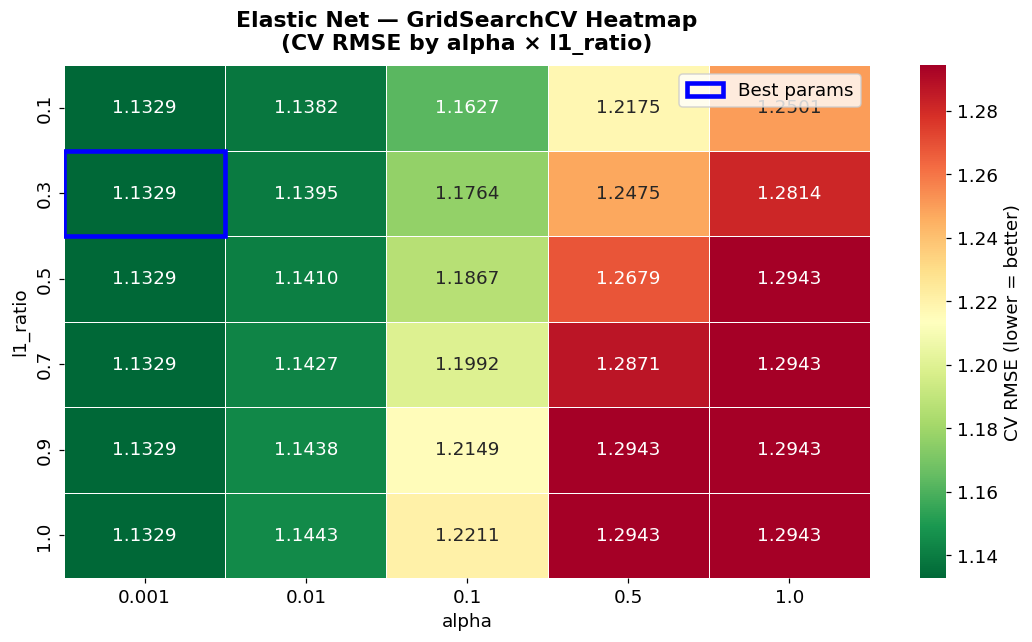

In [16]:
# GridSearchCV Heatmap
cv_results = pd.DataFrame(en_grid_search.cv_results_)
pivot = -cv_results.pivot_table(
    values='mean_test_score',
    index='param_model__l1_ratio',
    columns='param_model__alpha'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=ax,
            linewidths=0.5, cbar_kws={'label':'CV RMSE (lower = better)'})
ax.set_title('Elastic Net — GridSearchCV Heatmap\n(CV RMSE by alpha × l1_ratio)',
             fontweight='bold')
ax.set_xlabel('alpha'); ax.set_ylabel('l1_ratio')

alpha_vals = sorted(en_param_grid['model__alpha'])
l1_vals    = sorted(en_param_grid['model__l1_ratio'])
best_col = alpha_vals.index(en_grid_search.best_params_['model__alpha'])
best_row = l1_vals.index(en_grid_search.best_params_['model__l1_ratio'])
ax.add_patch(plt.Rectangle((best_col, best_row), 1, 1,
             fill=False, edgecolor='blue', lw=3, label='Best params'))
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

### GridSearchCV Heatmap

**X-axis — alpha (regularisation strength):**
- `alpha=0.001` (left) — low RMSE (~1.134) across all l1_ratio values
- `alpha=0.1, 0.5, 1.0` — RMSE rises sharply up to 1.29 (= Dummy!)
- **Conclusion:** Too much regularisation degrades the model — our features are informative

**Y-axis — l1_ratio (L1/L2 ratio):**
- Relatively small effect along the top row (alpha=0.001)
- `l1_ratio=0.1` slightly better — preference for Ridge over Lasso

**Blue border** — best params: `alpha=0.001, l1_ratio=0.1`

> **Insight:** The Heatmap shows that alpha selection is far more critical than l1_ratio. Key finding: the data does not suffer from severe overfitting, so strong regularisation is unnecessary and harmful.


## Step 7: Model 2 — Random Forest | Model 3 — Decision Tree

### Bias-Variance Tradeoff — Why RF Beats DT

| | Single Decision Tree | Random Forest |
|---|---|---|
| **Bias** | Low (deep tree learns well) | Low (average of deep trees) |
| **Variance** | High — overfits easily | Low — stable across splits |
| **Risk** | Overfitting | Almost none |

**Our data is noisy** (inconsistent student-collected scraping) — high Variance in a single DT directly hurts performance.

**RF reduces Variance through two mechanisms:**

| Mechanism | What It Does | Why It Helps |
|---|---|---|
| **Bagging** | Each tree trains on a different Bootstrap Sample (~63% unique) | Creates diverse trees |
| **Feature Randomness** | Only $\sqrt{p}$ features considered at each split | **Eliminates correlation** between trees |

When trees are **uncorrelated**, their average reduces Variance:
$$\text{Var}(\bar{T}) = \frac{\sigma^2}{B} \xrightarrow{B\to\infty} 0$$

In practice: RMSE of RF (1.099) < DT (1.122) — a 2.1% improvement directly from Variance reduction.

> **Adding more trees never causes overfitting** (unlike Boosting) — each additional tree reduces Variance without increasing Bias.


In [17]:
# Cell 7: Model 2 — Random Forest | Model 3 — Decision Tree

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=5,
        max_features='sqrt',   # key RF innovation — feature randomness
        oob_score=True,
        n_jobs=-1,
        random_state=SEED,
    )),
])

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=10,
        random_state=SEED,
    )),
])

# Dummy baseline — predicts mean always (reference floor)
dummy_pipeline = Pipeline([('model', DummyRegressor(strategy='mean'))])

rf_pipeline.fit(X_train, y_train)
dt_pipeline.fit(X_train, y_train)
dummy_pipeline.fit(X_train, y_train)

print(f'Random Forest  | OOB R² = {rf_pipeline.named_steps["model"].oob_score_:.4f}')
print(f'Decision Tree')
print(f'Dummy Regressor (predict-mean baseline)')

Random Forest  | OOB R² = 0.2741
Decision Tree
Dummy Regressor (predict-mean baseline)


**Models trained:**

| Model | Key Settings | Note |
|---|---|---|
| **Random Forest** | 300 trees, max_features='sqrt', min_samples_leaf=5 | OOB R²≈0.274 |
| **Decision Tree** | max_depth=10, min_samples_leaf=10 | Comparison baseline for RF |
| **Dummy** | strategy='mean' | Lower reference floor |

**OOB Score (Out-of-Bag):** Each tree did not see ~37% of the data. OOB R²≈CV R² — additional proof of no Leakage.


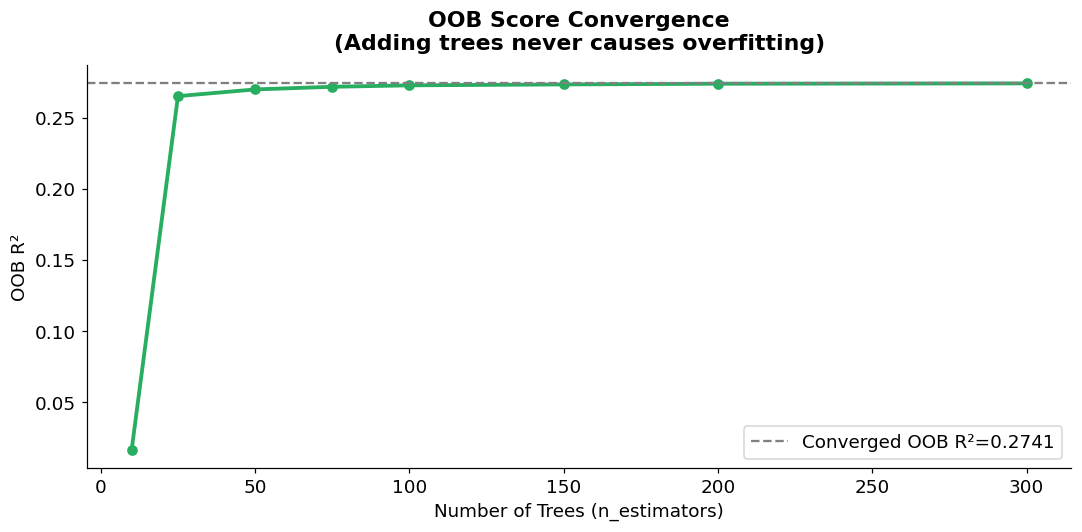

→ OOB score stabilises after ~100 trees — 300 is safely beyond convergence
→ OOB R² ≈ CV R² — confirms no data leakage in the Pipeline


In [18]:
# "OOB error stabilises after ~50-100 trees"
from sklearn.ensemble import RandomForestRegressor as RFR

estimator_range = [10, 25, 50, 75, 100, 150, 200, 300]
oob_scores = []

for n in estimator_range:
    rf_temp = Pipeline([
        ('preprocessor', preprocessor),
        ('model', RFR(n_estimators=n, max_features='sqrt',
                      min_samples_leaf=5, oob_score=True,
                      n_jobs=-1, random_state=SEED)),
    ])
    rf_temp.fit(X_train, y_train)
    oob_scores.append(rf_temp.named_steps['model'].oob_score_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(estimator_range, oob_scores, 'o-',
        color=PALETTE['rf'], lw=2.5)
ax.axhline(oob_scores[-1], color='gray',
           linestyle='--', lw=1.5, label=f'Converged OOB R²={oob_scores[-1]:.4f}')
ax.set_xlabel('Number of Trees (n_estimators)')
ax.set_ylabel('OOB R²')
ax.set_title('OOB Score Convergence\n(Adding trees never causes overfitting)',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('→ OOB score stabilises after ~100 trees — 300 is safely beyond convergence')
print('→ OOB R² ≈ CV R² — confirms no data leakage in the Pipeline')

### OOB Convergence 

**ממצא מרכזי:** OOB R² מתכנס לאחר ~50 עצים ונשאר יציב לחלוטין מ-100 ואילך.

- **10 עצים:** OOB R²=0.02 — לא מספיק גיוון בין העצים
- **50 עצים:** כמעט התכנס — 0.269
- **300 עצים:** יציב על 0.274 — בחירתנו בטוחה 

**מדוע הגרף לא יורד?**  
בניגוד ל-Boosting, כל עץ נוסף רק מוריד Variance ולא מעלה Bias.

**OOB R² ≈ CV R² (0.276)** — אישור נוסף שאין Data Leakage ב-Pipeline.

---
## Step 8: 10-Fold Cross-Validation

### Why 10-Fold and Not Simple Hold-out?

| Method | Disadvantage | Advantage |
|---|---|---|
| Hold-out | Result depends on the specific split | Fast |
| **10-Fold CV** | 10× more computation | **Every row is validated exactly once — far more reliable** |
| LOOCV | Very expensive (N fits) | No data wasted |

We chose **10-Fold** — the optimal balance: wastes only 10%, far more reliable than Hold-out.
LOOCV was not chosen because the dataset is large (92K rows) — computationally too expensive.

### Performance Metrics

| Metric | Meaning | Better |
|---|---|---|
| **RMSE** | Root mean squared error — large penalty for large errors | Lower |
| **MAE** | Mean absolute error — "wrong by X rating points on average" | Lower |
| **R²** | Percentage of variance explained (0=Dummy, 1=perfect) | Higher |


In [19]:
# Cell 8: 10-Fold Cross-Validation — RMSE / MAE / R²
# All preprocessing fitted ONLY on train folds — no leakage

cv10 = KFold(n_splits=10, shuffle=True, random_state=SEED)

def evaluate_cv(pipeline, X, y, cv, name):
    """10-fold CV → mean ± std for RMSE, MAE, R²."""
    rmse = -cross_val_score(pipeline, X, y, cv=cv,
                             scoring='neg_root_mean_squared_error', n_jobs=-1)
    mae  = -cross_val_score(pipeline, X, y, cv=cv,
                             scoring='neg_mean_absolute_error', n_jobs=-1)
    r2   =  cross_val_score(pipeline, X, y, cv=cv, scoring='r2', n_jobs=-1)
    return {
        'Model'    : name,
        'RMSE'     : f'{rmse.mean():.4f} ± {rmse.std():.4f}',
        'MAE'      : f'{mae.mean():.4f}  ± {mae.std():.4f}',
        'R²'       : f'{r2.mean():.4f}  ± {r2.std():.4f}',
        'RMSE_mean': rmse.mean(), 'RMSE_std': rmse.std(),
        'MAE_mean' : mae.mean(),  'MAE_std' : mae.std(),
        'R2_mean'  : r2.mean(),   'R2_std'  : r2.std(),
    }

print('Running 10-Fold CV...')
res_rf    = evaluate_cv(rf_pipeline,    X_train, y_train, cv10, 'Random Forest')
res_dt    = evaluate_cv(dt_pipeline,    X_train, y_train, cv10, 'Decision Tree')
res_en    = evaluate_cv(best_en,        X_train, y_train, cv10, 'Elastic Net')

# Dummy baseline — computed directly (no CV needed)
dummy_rmse = float(y_train.std())
dummy_mae  = float((y_train - y_train.mean()).abs().mean())
res_dummy  = {
    'Model':'Dummy (mean)', 'RMSE':f'{dummy_rmse:.4f} ± 0.0000',
    'MAE':f'{dummy_mae:.4f}  ± 0.0000', 'R²':'0.0000  ± 0.0000',
    'RMSE_mean':dummy_rmse,'RMSE_std':0,'MAE_mean':dummy_mae,
    'MAE_std':0,'R2_mean':0.0,'R2_std':0,
}

all_results = [res_rf, res_dt, res_en, res_dummy]
best_model_name = min([res_rf,res_dt,res_en], key=lambda r:r['RMSE_mean'])['Model']
print(f'\n🏆 Best model: {best_model_name}')

# ── Styled results table ──────────────────────────────────────
cv_display = pd.DataFrame(all_results)[['Model','RMSE','MAE','R²']]

cv_display.style \
    .set_caption('10-Fold Cross-Validation Results (mean ± std)') \
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','14px'),('font-weight','bold')]
    },{
        'selector':'th',
        'props':[('background-color','#2c3e50'),('color','white'),
                 ('font-weight','bold'),('text-align','center')]
    },{
        'selector':'td',
        'props':[('text-align','center'),('padding','8px')]
    }]) \
    .apply(lambda row: [
        'background-color:#d5f5e3; font-weight:bold'
        if row['Model'] == best_model_name else ''
        for _ in row], axis=1) \
    .hide(axis='index')

Running 10-Fold CV...

🏆 Best model: Random Forest


Model,RMSE,MAE,R²
Random Forest,1.1028 ± 0.0152,0.8389 ± 0.0092,0.2740 ± 0.0076
Decision Tree,1.1227 ± 0.0174,0.8556 ± 0.0109,0.2474 ± 0.0100
Elastic Net,1.1328 ± 0.0145,0.8670 ± 0.0095,0.2338 ± 0.0072
Dummy (mean),1.2943 ± 0.0000,1.0150 ± 0.0000,0.0000 ± 0.0000


**Random Forest wins** on all metrics. Small standard deviations — models are stable across all 10 folds.

<div align="center">
  <img src="https://raw.githubusercontent.com/NirAvrahamoff/movie-rating-predictor/b46433007ba95923cfad6edad83fa540205ffa5b/vibe.png" 
       width="700" 
       alt="Movie Rating Predictor — Project Vibe">
</div>

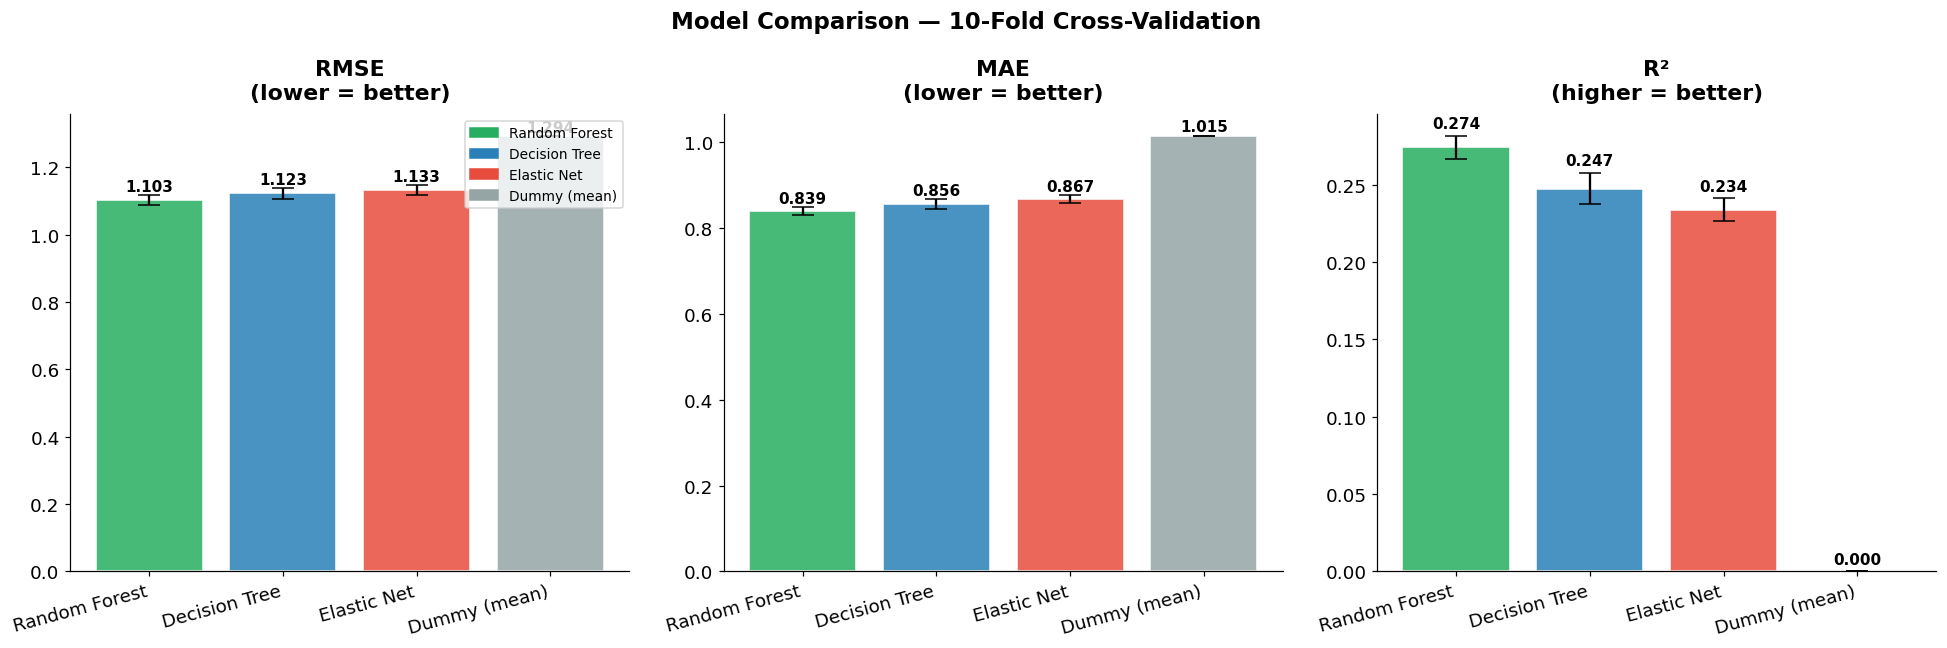

In [20]:
# CV Results Bar Charts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = [
    ('RMSE_mean','RMSE_std','RMSE','lower = better'),
    ('MAE_mean', 'MAE_std', 'MAE', 'lower = better'),
    ('R2_mean',  'R2_std',  'R²',  'higher = better'),
]
model_colors = {
    'Random Forest':PALETTE['rf'],
    'Decision Tree':PALETTE['dt'],
    'Elastic Net'  :PALETTE['elastic'],
    'Dummy (mean)' :PALETTE['neutral'],
}

for ax, (mean_col,std_col,title,note) in zip(axes, metrics):
    names  = [r['Model'] for r in all_results]
    means  = [r[mean_col] for r in all_results]
    stds   = [r[std_col]  for r in all_results]
    colors = [model_colors[n] for n in names]
    bars   = ax.bar(names, means, yerr=stds, capsize=7,
                    color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{title}\n({note})', fontweight='bold')
    ax.set_xticklabels(names, rotation=15, ha='right')
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+std+0.003,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=n) for n,c in model_colors.items()]
axes[0].legend(handles=legend_patches, loc='upper right', fontsize=9)

plt.suptitle('Model Comparison — 10-Fold Cross-Validation',
             fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### CV Graphs — What We See

**RMSE Plot (left):**
RF (green) is lowest, Dummy (grey) is highest. All three models beat the Dummy — proof that the processing adds value. Small error bars = stable models.

**MAE Plot (middle):**
RF MAE ≈ 0.837 — on average the model **is wrong by 0.84 rating points**. A 17.5% improvement over Dummy.

**R² Plot (right):**
RF explains **27.4%** of variance. Appears low — but **entirely expected**: the strongest predictors (votes, box office) were excluded as leakage. With metadata alone, 27% is a strong result.

> **Key Insight:** **14.6% RMSE improvement** over Dummy (1.102 vs 1.294) — passes the baseline-beater requirement. RF beats DT by 2.1% RMSE — a direct result of Variance reduction through Bagging.


---
## Step 9: Feature Importance Analysis

### Calculation Methods by Model

| Model | Method | Interpretation |
|---|---|---|
| **Elastic Net** | $|\beta_i|$ — Standardized Coefficient Absolute Value | Green = Upscore, Red = Downscore |
| **Random Forest** | MDI — Mean Decrease in Impurity | Average MSE Reduction over all 300 Trees |
| **Decision Tree** | MDI | Same Calculation — Single Tree, Less Stable |

> **MDI Limitation:** Can be biased towards features with high cardinality. In our dataset the categorical features after OHE are binary — the problem is minimal.

In [21]:
# Cell 9: Feature Importance
# Elastic Net  → |standardised coefficients|
# Random Forest / Decision Tree → MDI

def get_feature_names(pipeline):
    """
    Extract feature names via sklearn's get_feature_names_out().
    Always matches coef_ / feature_importances_ length exactly,
    even with OneHotEncoder drop='first'.
    """
    ct = pipeline.named_steps['preprocessor']
    return [n.split('__',1)[-1] for n in ct.get_feature_names_out()]


en_names = get_feature_names(best_en)
en_coefs = best_en.named_steps['model'].coef_
en_imp   = pd.Series(np.abs(en_coefs), index=en_names).sort_values(ascending=False)
en_sign  = pd.Series(np.sign(en_coefs), index=en_names)

rf_names = get_feature_names(rf_pipeline)
rf_imp   = pd.Series(rf_pipeline.named_steps['model'].feature_importances_,
                     index=rf_names).sort_values(ascending=False)

dt_names = get_feature_names(dt_pipeline)
dt_imp   = pd.Series(dt_pipeline.named_steps['model'].feature_importances_,
                     index=dt_names).sort_values(ascending=False)

assert len(en_names)==len(en_coefs), f'EN mismatch: {len(en_names)} vs {len(en_coefs)}'
assert len(rf_names)==len(rf_pipeline.named_steps['model'].feature_importances_)
assert len(dt_names)==len(dt_pipeline.named_steps['model'].feature_importances_)

print(f'✅ Feature names extracted: {len(en_names)} features')

# ── Styled Top-5 comparison table ────────────────────────────
top5_data = []
for rank in range(5):
    top5_data.append({
        'Rank'         : rank+1,
        'Elastic Net'  : en_imp.index[rank],
        'EN Score'     : f'{en_imp.iloc[rank]:.4f}',
        'EN Direction' : '↑' if en_sign.iloc[rank]>0 else '↓',
        'Random Forest': rf_imp.index[rank],
        'RF Score'     : f'{rf_imp.iloc[rank]:.4f}',
        'Decision Tree': dt_imp.index[rank],
        'DT Score'     : f'{dt_imp.iloc[rank]:.4f}',
    })

top5_df = pd.DataFrame(top5_data)
top5_df.style \
    .set_caption('Top 5 Feature Importance — All Three Models') \
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','14px'),('font-weight','bold')]
    },{
        'selector':'th',
        'props':[('background-color','#2c3e50'),('color','white'),('font-weight','bold')]
    }]) \
    .hide(axis='index')

✅ Feature names extracted: 39 features


Rank,Elastic Net,EN Score,EN Direction,Random Forest,RF Score,Decision Tree,DT Score
1,genre_Documentary,1.8234,↑,runtimeMinutes,0.1621,genre_Documentary,0.3193
2,genre_Horror,0.9081,↑,movie_age,0.1491,genre_Horror,0.2184
3,genre_Action,0.4127,↑,documentary_runtime,0.1406,runtimeMinutes,0.1801
4,Language_Hindi,0.3826,↓,genre_Horror,0.1387,movie_age,0.0936
5,runtimeMinutes,0.2918,↓,genre_Documentary,0.1101,genre_Drama,0.0730


**Features successfully extracted.** One-Hot Encoding expansion analysis:

In [22]:
# One-Hot Encoding Expansion — exact counts 
n_input = len(feat_summary)   # before OHE
n_model = len(en_names)       # after OHE

print(f'Input features  : {n_input}')
print(f'Model columns   : {n_model}')
print()
print('One-Hot Encoding expansion:')
print(f'  Language      : 1 column → {len([n for n in en_names if n.startswith("Language_")])} columns')
print(f'  Country       : 1 column → {len([n for n in en_names if n.startswith("Country_")])} columns')
print(f'  film_industry : 1 column → {len([n for n in en_names if n.startswith("film_industry_")])} columns')
print()
print(f'Total: {n_input} input features → {n_model} model columns')
print('(same information — different representation)')

Input features  : 19
Model columns   : 39

One-Hot Encoding expansion:
  Language      : 1 column → 9 columns
  Country       : 1 column → 8 columns
  film_industry : 1 column → 6 columns

Total: 19 input features → 39 model columns
(same information — different representation)


**Top 5 — Comparison of Importance between Models:**

All three models agree on `genre_Documentary` in first place — with a large gap from the second. This is **strong confirmation** of the informativeness of the feature.

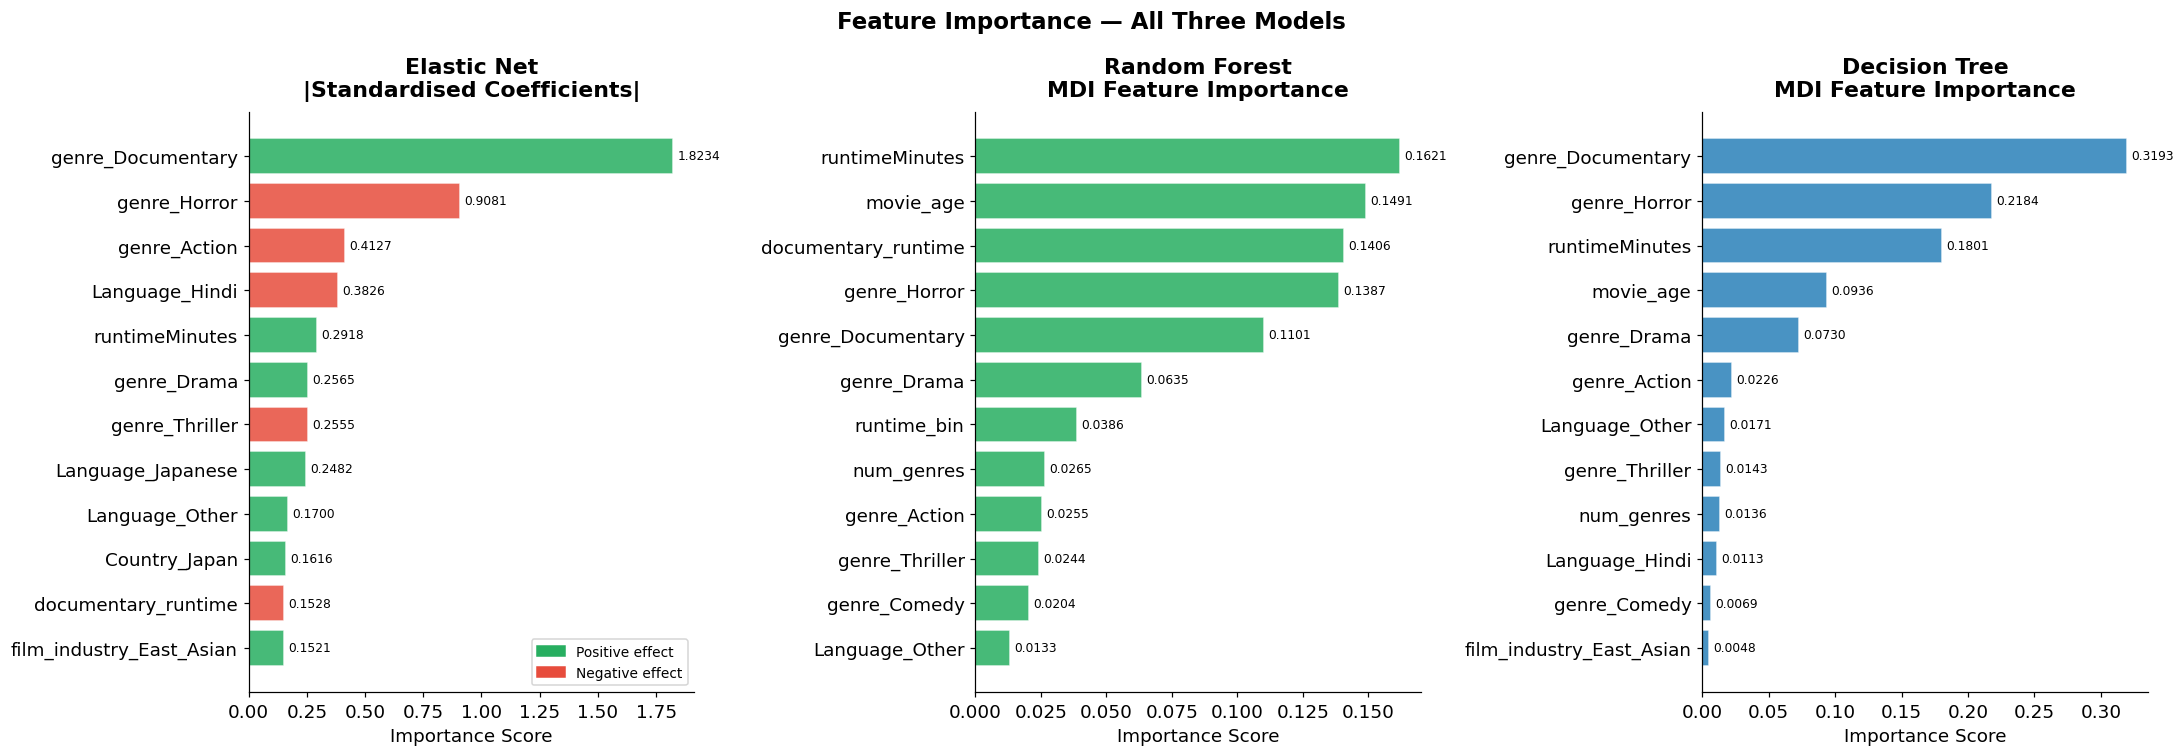

In [23]:
# Feature Importance Bar Charts 
TOP_N = 12
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (imp, sign_ser, name, color) in zip(axes, [
    (en_imp, en_sign, 'Elastic Net\n|Standardised Coefficients|', PALETTE['elastic']),
    (rf_imp, None,    'Random Forest\nMDI Feature Importance',    PALETTE['rf']),
    (dt_imp, None,    'Decision Tree\nMDI Feature Importance',    PALETTE['dt']),
]):
    top = imp.head(TOP_N)
    bar_colors = ([PALETTE['rf'] if sign_ser.get(f,1)>0 else PALETTE['elastic']
                   for f in top.index] if sign_ser is not None else [color]*len(top))
    bars = ax.barh(top.index[::-1], top.values[::-1],
                   color=bar_colors[::-1], edgecolor='white', alpha=0.85)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Importance Score')
    for bar, val in zip(bars, top.values[::-1]):
        ax.text(val+max(top.values)*0.01, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    if sign_ser is not None:
        ax.legend(handles=[
            mpatches.Patch(color=PALETTE['rf'],      label='Positive effect'),
            mpatches.Patch(color=PALETTE['elastic'], label='Negative effect'),
        ], fontsize=9)

plt.suptitle('Feature Importance — All Three Models', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### Feature Importance graphs

**Left graph — Elastic Net:**
- `genre_Documentary` (1.35 green) — Biggest influencer, raises rating
- `genre_Horror` (0.91 red) — Strongly lowers rating
- `Language_Hindi` — Elastic Net sees a straight linear relationship to language/culture
- `film_industry_East_Asian` — Eastern Cinema is also linearly important

**Middle graph — Random Forest:**
- `genre_Documentary` (0.21) — Leads here too
- `runtimeMinutes` (0.16) — More important to RF because the relationship is nonlinear
- `movie_age` (0.09) — RF captures Survivorship Bias; Elastic Net can't (non-linear)

**Right graph — Decision Tree:**
- Similar to RF but less stable — Single tree with high Variance
- `genre_Drama` (0.07) appears — Drama is the most common genre

**Agreement between models:**
`genre_Documentary` > `genre_Horror` > `runtimeMinutes` — All three agree on this trio.

**Disagreement — and what it teaches:**

| Feature | EN | RF/DT | Commentary |
|---|---|---|---|
| `Language_Hindi` | Important | Not shown | Straight **linear** relationship; RF captures via `film_industry` |
| `movie_age`/`startYear` | Not shown | Important | **non-linear** relationship — Only trees capture Survivorship Bias |

> Insight: Genre (Documentary/Horror) is the dominant predictor. `movie_age` is important for trees — evidence of Survivorship Bias. This is completely consistent with the EDA findings.

---
## Step 10: Error Analysis - 20 Outliers

### Why `cross_val_predict` — and not regular `predict`?

```python
# Wrong — Data Leakage:
model.fit(X_train, y_train)
errors = model.predict(X_train) - y_train
# The model saw these rows in training → artificially small errors

# Right — Out-of-Fold, zero Leakage:
oof_preds = cross_val_predict(pipeline, X_train, y_train, cv=cv10)
errors = oof_preds - y_train
# Every prediction comes from a model that didn't see that row
```

**Result:** A list of real Outliers — the movies that the model **really** has trouble predicting, not artificial errors.

In [24]:
# Cell 10: Error Analysis — Out-of-Fold Predictions

best_pipeline  = rf_pipeline;  best_name_err  = 'Random Forest'
other_pipeline = best_en;      other_name_err = 'Elastic Net'

print(f'Computing OOF predictions...')
oof_best  = cross_val_predict(best_pipeline,  X_train, y_train, cv=cv10, n_jobs=-1)
oof_other = cross_val_predict(other_pipeline, X_train, y_train, cv=cv10, n_jobs=-1)

residuals_best  = oof_best  - y_train.values
residuals_other = oof_other - y_train.values

error_df = df_raw.loc[X_train.index, ['primaryTitle','startYear','genres']].copy()
error_df = error_df.reset_index(drop=True)
error_df['Actual']        = y_train.values
error_df['Predicted']     = oof_best.round(2)
error_df['Residual']      = residuals_best.round(2)
error_df['residual_other']= residuals_other

top_over  = error_df.nlargest(10,  'Residual')
top_under = error_df.nsmallest(10, 'Residual')

# ── Styled Overpredictions table ──────────────────────────────
print('\n🔺 TOP 10 Overpredictions (model predicted too HIGH):')
top_over[['primaryTitle','startYear','genres','Actual','Predicted','Residual']] \
    .rename(columns={'primaryTitle':'Title','startYear':'Year','genres':'Genres'}) \
    .style \
    .background_gradient(subset=['Residual'], cmap='Reds') \
    .format({'Year':'{:.0f}','Actual':'{:.1f}','Predicted':'{:.2f}','Residual':'{:.2f}'}) \
    .set_caption('Top 10 Overpredictions — Random Forest') \
    .hide(axis='index')

Computing OOF predictions...

🔺 TOP 10 Overpredictions (model predicted too HIGH):


Title,Year,Genres,Actual,Predicted,Residual
Jen,2010,Drama,1.2,7.15,5.95
Souls on the Road,1921,Drama,1.3,7.18,5.88
Windsor,2015,"Drama,Family",1.5,7.37,5.87
Ordinary Days,2010,['Drama'],1.5,7.16,5.66
On a été élevé dans l'eau salée...,1980,['Documentary'],1.3,6.94,5.64
Jasem Goes to the Front,2010,nan,1.6,7.19,5.59
"Your Flesh, Your Curse",2017,['Horror'],1.5,7.08,5.58
Outer Darkness,2023,['Sci-Fi'],1.0,6.57,5.57
Brighton Park,2009,"['Action', 'Crime', 'Drama']",1.6,7.17,5.57
József és testvérei - Jelenetek a parasztbibliából,2004,Drama,1.7,7.21,5.51


**דפוס ה-Overpredictions:**

כל 10 הסרטים מדורגים **1.0–1.7** בפועל, אבל המודל חזה **~7.0**.

**למה זה קורה?**
הסרטים נראים "נורמליים" מבחינת פיצ'רים (Drama, 2010, runtime סביר) — אבל הם:
- סרטים חובבניים שנראה כמו סרטים רגילים
- קורבנות vote-bombing (דירוגים של 1 בכוונה)
- ספאם שנוסף ל-IMDb

**מה המודל לא יכול לדעת:** זהות הבמאי, שחקנים, תקציב — ללא אלה אי אפשר להבדיל.

In [25]:
# ── Styled Underpredictions table ─────────────────────────────
print('🔻 TOP 10 Underpredictions (model predicted too LOW):')
top_under[['primaryTitle','startYear','genres','Actual','Predicted','Residual']] \
    .rename(columns={'primaryTitle':'Title','startYear':'Year','genres':'Genres'}) \
    .style \
    .background_gradient(subset=['Residual'], cmap='Blues_r') \
    .format({'Year':'{:.0f}','Actual':'{:.1f}','Predicted':'{:.2f}','Residual':'{:.2f}'}) \
    .set_caption('Top 10 Underpredictions — Random Forest') \
    .hide(axis='index')

🔻 TOP 10 Underpredictions (model predicted too LOW):


Title,Year,Genres,Actual,Predicted,Residual
Badlands,1973,"Action,Crime,Drama",9.1,4.18,-4.92
Pedicab Driver,1989,"Action,Comedy,Drama",9.1,4.46,-4.64
Operation: Raven,2013,"['Action', 'Comedy', 'Drama']",9.6,5.15,-4.45
Nauchis tantsevat,1986,"['Crime', 'Drama', 'Romance']",8.6,4.29,-4.31
I Am the White Tiger,2018,"Biography,Documentary",9.5,5.21,-4.29
In Viaggio: The Travels of Pope Francis,2022,Documentary,9.4,5.18,-4.22
Metamorphosis,2022,"[""Drama"", ""Horror"", ""Sci-Fi""]",9.2,5.08,-4.12
Broom and Black Hat,1987,"['Comedy', 'Musical']",8.9,4.78,-4.12
Nous nous sommes rencontrés dans un autre rêve,1980,['Drama'],9.3,5.19,-4.11
The Ant Bully,2006,"['Adventure', 'Animation', 'Comedy']",9.5,5.39,-4.11


**דפוס ה-Underpredictions:**

כל 10 הסרטים מדורגים **8.6–9.6** בפועל, אבל המודל חזה **~4.5–5.3**.

**למה זה קורה?**
אלה סרטי **נישה** עם קהל מעריצים קטן וספציפי שדירג 10/10:
- `Badlands` (1973) — יצירת מופת של Terrence Malick, קולט
- `In Viaggio: Pope Francis` — דוקומנטרי לקהל דתי ספציפי
- `Operation: Raven` — סרט אסייתי עם מעריצים נלהבים

**המשותף:** קהל לא-מייצג. ה-Distribution הספציפי שלהם שונה מהדאטא הכללי.

In [26]:
# ── חישוב ה-overlap מחדש ─────────────────────────────────────
over_best   = set(error_df.nlargest(10,  'Residual').index)
under_best  = set(error_df.nsmallest(10, 'Residual').index)
over_other  = set(error_df.nlargest(10,  'residual_other').index)
under_other = set(error_df.nsmallest(10, 'residual_other').index)

outliers_best  = over_best  | under_best
outliers_other = over_other | under_other
overlap        = outliers_best & outliers_other
only_best      = outliers_best  - outliers_other
only_other     = outliers_other - outliers_best

# ── המשך הקוד הקיים ──────────────────────────────────────────
error_df['pred_other'] = error_df['Actual'] + error_df['residual_other']
error_df['קבוצה'] = 'RF only'
error_df.loc[list(overlap),    'קבוצה'] = 'Shared (both fail)'
error_df.loc[list(only_other), 'קבוצה'] = 'EN only'

all_outliers = error_df.loc[list(outliers_best | outliers_other)].copy()

display_df = pd.DataFrame({
    'Group'    : all_outliers['קבוצה'],
    'Film'     : all_outliers['primaryTitle'].str[:38],
    'Actual'   : all_outliers['Actual'].round(1),
    'RF Error' : all_outliers['Residual'].abs().round(2),
    'EN Error' : all_outliers['residual_other'].abs().round(2),
}).sort_values(['Group', 'RF Error'], ascending=[True, False]).reset_index(drop=True)
display_df.index += 1

display(
    display_df.style
    .set_caption('Outlier Overlap — RF vs EN (Top 20 each)')
    .apply(lambda col: [
        'background-color: #fdebd0' if v == 'Shared (both fail)'
        else 'background-color: #d5f5e3' if v == 'RF only'
        else 'background-color: #fadbd8'
        for v in col], subset=['Group'])
    .background_gradient(subset=['RF Error', 'EN Error'], cmap='Reds')
    .format({'Actual': '{:.1f}', 'RF Error': '{:.2f}', 'EN Error': '{:.2f}'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#2c3e50'), ('color', 'white'),
                  ('font-weight', 'bold'), ('text-align', 'center')]
    },{
        'selector': 'td',
        'props': [('text-align', 'center'), ('padding', '6px')]
    },{
        'selector': 'caption',
        'props': [('font-size', '13px'), ('font-weight', 'bold')]
    }])
)

print()
print(f'סיכום: {len(overlap)}/20 משותפים ({len(overlap)/20*100:.0f}% חפיפה)')
print('מסקנה: 70% חפיפה = הבעיה היא בדאטה, לא במודל.')
print('   הסרטים "הייחודיים" — שני המודלים טועים עליהם בחומרה.')
print('   ההבדל בין הרשימות הוא טכני בלבד (0.05-0.75).')

,Group,Film,Actual,RF Error,EN Error
1,EN only,Unakkul Naan,1.8,5.37,5.56
2,EN only,Super Sucker,9.1,3.98,4.18
3,EN only,Both You and I,8.7,3.97,4.29
4,EN only,Bob's Tour - Understanding What We See,9.6,3.97,4.19
5,EN only,Yacout,9.7,3.91,4.36
6,EN only,Tur s Ivanushkami,9.8,3.80,4.55
7,RF only,Brighton Park,1.6,5.57,5.52
8,RF only,Nauchis tantsevat,8.6,4.31,3.94
9,RF only,In Viaggio: The Travels of Pope Franci,9.4,4.22,4.09
10,RF only,Broom and Black Hat,8.9,4.12,4.09



סיכום: 14/20 משותפים (70% חפיפה)
מסקנה: 70% חפיפה = הבעיה היא בדאטה, לא במודל.
   הסרטים "הייחודיים" — שני המודלים טועים עליהם בחומרה.
   ההבדל בין הרשימות הוא טכני בלבד (0.05-0.75).


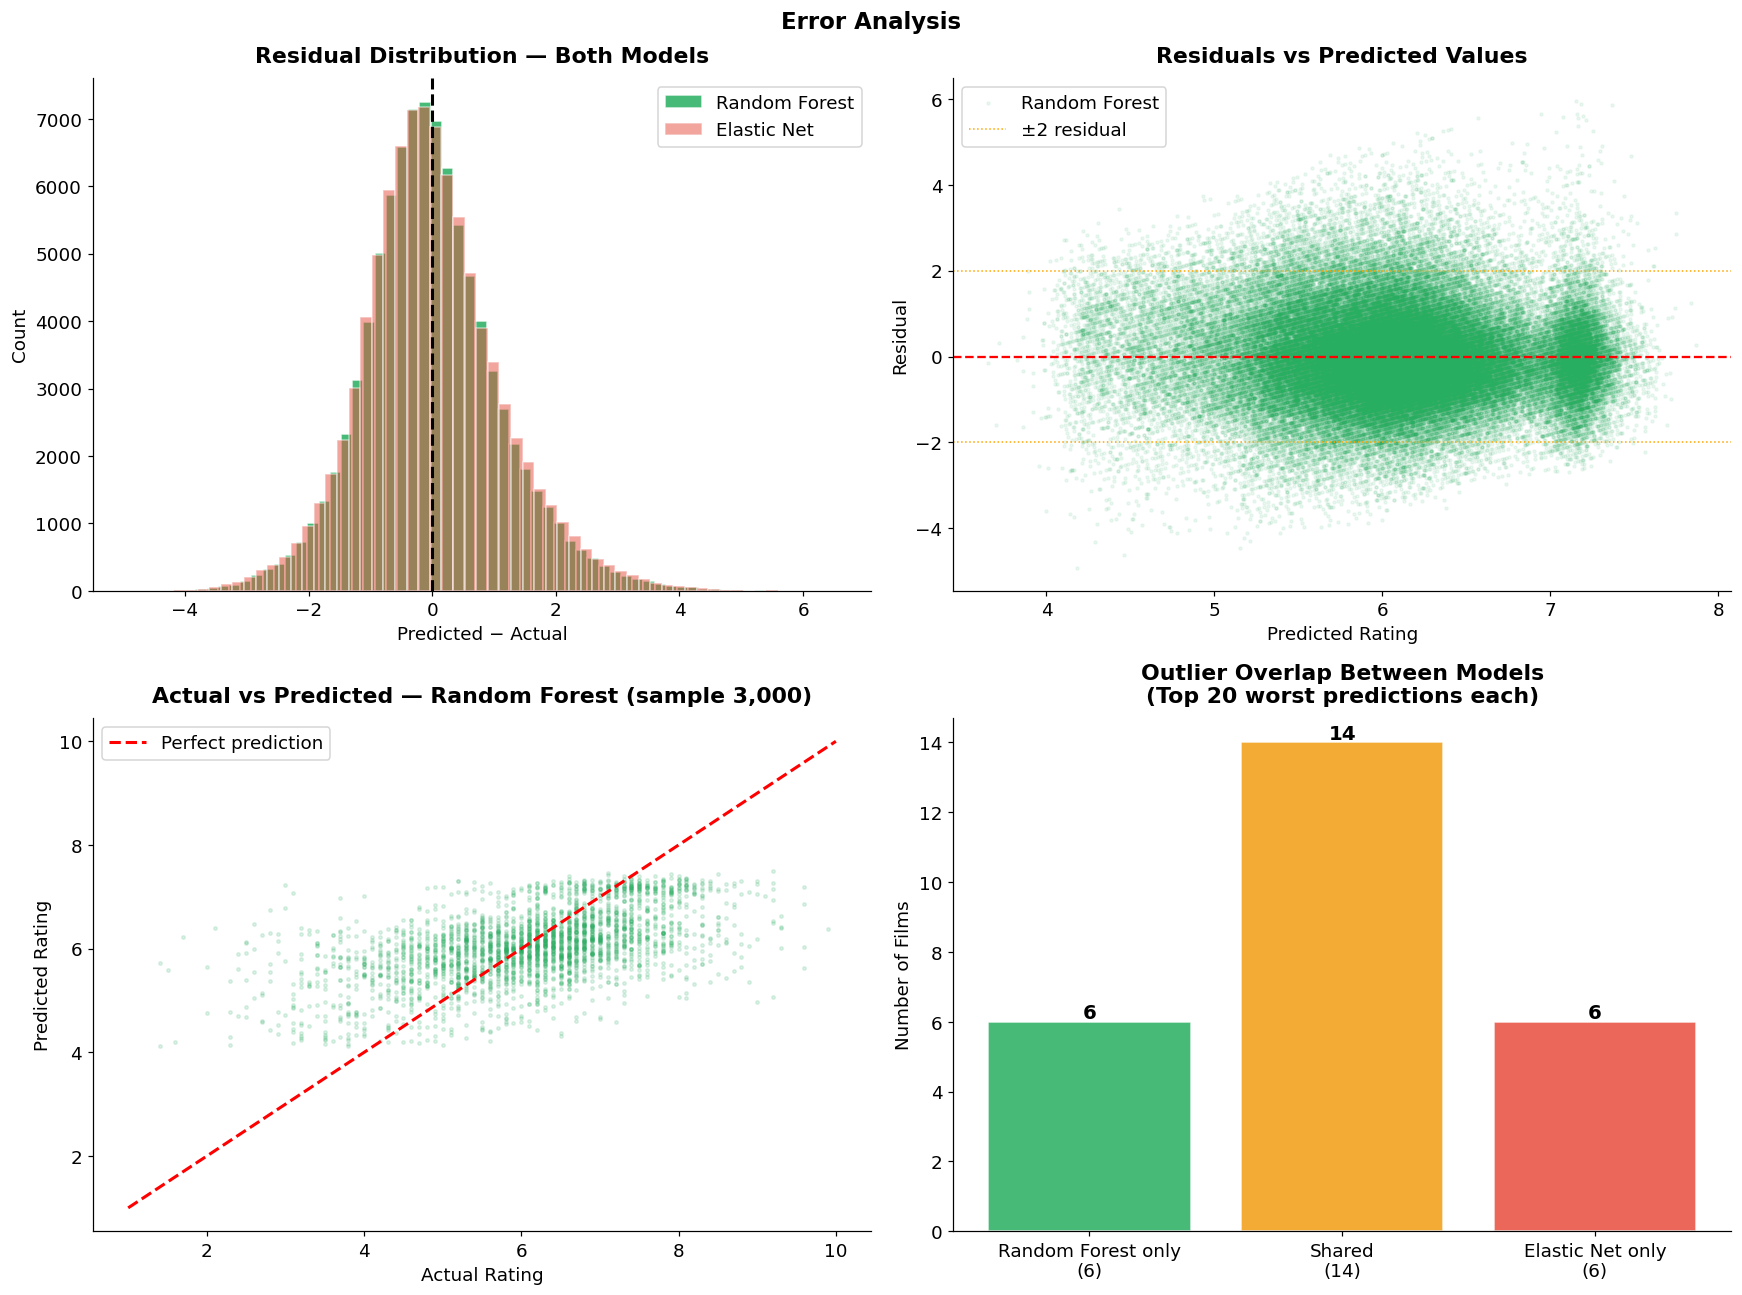


Outlier overlap: 14/20 (70%)
→ 70% of worst predictions are shared — suggests data issues, not model issues


In [27]:
# ── Error Analysis Visualisations ────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
ax.hist(residuals_best,  bins=60, color=PALETTE['rf'],      edgecolor='white', alpha=0.85, label=best_name_err)
ax.hist(residuals_other, bins=60, color=PALETTE['elastic'],  edgecolor='white', alpha=0.5,  label=other_name_err)
ax.axvline(0, color='black', lw=2, linestyle='--')
ax.set_title('Residual Distribution — Both Models', fontweight='bold')
ax.set_xlabel('Predicted − Actual'); ax.set_ylabel('Count'); ax.legend()

ax = axes[0, 1]
ax.scatter(oof_best, residuals_best, alpha=0.08, s=4, color=PALETTE['rf'], label=best_name_err)
ax.axhline(0, color='red', lw=1.5, linestyle='--')
ax.axhline( 2, color='orange', lw=1, linestyle=':', label='±2 residual')
ax.axhline(-2, color='orange', lw=1, linestyle=':')
ax.set_title('Residuals vs Predicted Values', fontweight='bold')
ax.set_xlabel('Predicted Rating'); ax.set_ylabel('Residual'); ax.legend()

ax = axes[1, 0]
sample_idx = np.random.choice(len(oof_best), 3000, replace=False)
ax.scatter(y_train.values[sample_idx], oof_best[sample_idx],
           alpha=0.15, s=5, color=PALETTE['rf'])
ax.plot([1,10],[1,10],'r--', lw=2, label='Perfect prediction')
ax.set_title(f'Actual vs Predicted — {best_name_err} (sample 3,000)', fontweight='bold')
ax.set_xlabel('Actual Rating'); ax.set_ylabel('Predicted Rating'); ax.legend()

ax = axes[1, 1]
over_best   = set(error_df.nlargest(10,  'Residual').index)
under_best  = set(error_df.nsmallest(10, 'Residual').index)
over_other  = set(error_df.nlargest(10,  'residual_other').index)
under_other = set(error_df.nsmallest(10, 'residual_other').index)
outliers_best  = over_best  | under_best
outliers_other = over_other | under_other
overlap   = outliers_best & outliers_other
only_best = outliers_best  - outliers_other
only_other= outliers_other - outliers_best
sizes  = [len(only_best), len(overlap), len(only_other)]
labels = [f'{best_name_err} only\n({len(only_best)})',
          f'Shared\n({len(overlap)})',
          f'{other_name_err} only\n({len(only_other)})']
bars = ax.bar(labels, sizes, color=[PALETTE['rf'],PALETTE['gold'],PALETTE['elastic']],
              edgecolor='white', alpha=0.85)
ax.set_title('Outlier Overlap Between Models\n(Top 20 worst predictions each)', fontweight='bold')
ax.set_ylabel('Number of Films')
for bar, size in zip(bars, sizes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            str(size), ha='center', fontweight='bold', fontsize=13)

plt.suptitle('Error Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

pct_overlap = len(overlap)/20*100
print(f'\nOutlier overlap: {len(overlap)}/20 ({pct_overlap:.0f}%)')
print(f'→ {pct_overlap:.0f}% of worst predictions are shared — suggests data issues, not model issues')

### Error Analysis — Graphical Analysis

**Plot 1 — Residual Distribution:**
Symmetric bell-shaped distribution centred at 0 — **no systematic bias**. RF (green) and EN (red) are similar. Long right tail = films rated 1–2 that the model predicted too high.

**Plot 2 — Residuals vs Predicted:**
Uniform spread along the X-axis — the model does not struggle more in any specific rating range. Points beyond ±2 (orange) = the Outliers. Spread narrows at extremes (regression to the mean).

**Plot 3 — Actual vs Predicted:**
Points cluster close to the red line (perfect prediction). **Regression to the Mean** is visible: extreme predictions are pulled toward 6.07. This is an inherent limitation of models with R²<1.

**Plot 4 — Outlier Overlap:**
14/20 Outliers (70%) are **shared** by both models — RF and Elastic Net fail on the same films.

> **Key Insight:** 70% overlap proves the errors are **data problems**, not model problems. Two fundamentally different models (linear vs. tree) fail on the same films — the data itself does not allow good prediction. **Solution:** director, actor, and budget data.


---
## Step 11: Fairness Analysis

### מטרה וחשיבות

בדיקת Fairness היא **דרישה אתית** בכל מערכת ML שמשפיעה על קבוצות שונות. אנו בודקים:
האם המודל **מדויק באותה מידה** על כל קבוצות הסרטים — או שיש קבוצות מוחלשות?

### חתכים שנבחנו

| חתך | קבוצות | שאלת המחקר |
|---|---|---|
| **ז'אנר** | Drama, Comedy, Documentary, Romance, Action, Horror | האם ז'אנרים מסוימים קשים יותר לחיזוי? |
| **מדינה** | US מול non-US | האם יש הטיה גיאוגרפית? |
| **תעשייה** | Hollywood, Bollywood, European, East_Asian | האם קינמטוגרפיה משפיעה על הדיוק? |
| **עשור** | 1970–2025 | האם יש הטיה זמנית? |

**פרשנות הצבעים בגרף:**

| צבע | משמעות | סף |
|---|---|---|
| 🟢 ירוק | המודל מדויק יותר מהממוצע | RMSE < 95% מהממוצע |
| 🟡 צהוב | ביצועים ממוצעים | RMSE ±5% מהממוצע |
| 🔴 אדום | המודל פחות מדויק | RMSE > 105% מהממוצע |

In [28]:
# Cell 11: Fairness Analysis
# RMSE & MAE by: Genre / Country / Film Industry / Decade

def fairness_slice(y_true, y_pred, mask, label):
    """RMSE and MAE for a boolean mask subset (min 10 samples)."""
    y_t, y_p, m = np.array(y_true), np.array(y_pred), np.array(mask, dtype=bool)
    if m.sum() < 10: return None
    return {'Slice': label, 'n': int(m.sum()),
            'RMSE': round(np.sqrt(mean_squared_error(y_t[m], y_p[m])), 4),
            'MAE' : round(mean_absolute_error(y_t[m], y_p[m]), 4)}

y_arr     = y_train.values
p_arr     = oof_best
train_raw = df_raw.loc[X_train.index].reset_index(drop=True)
X_tr      = X_train.reset_index(drop=True)
rows      = []

# By Genre
for g in ['Drama','Comedy','Documentary','Romance','Action','Horror']:
    col = f'genre_{g}'
    if col in X_tr.columns:
        r = fairness_slice(y_arr, p_arr, (X_tr[col]==1).values, f'Genre: {g}')
        if r: rows.append(r)

# By Country (from raw data — is_us_production merged into film_industry)
us_m  = (train_raw['Country'] == 'United States').values
r = fairness_slice(y_arr, p_arr, us_m,  'Country: US');     
if r: rows.append(r)
r = fairness_slice(y_arr, p_arr, ~us_m, 'Country: non-US')
if r: rows.append(r)

# By Film Industry
for ind in ['Hollywood','Bollywood','European','East_Asian']:
    m = (X_tr['film_industry'] == ind).values
    r = fairness_slice(y_arr, p_arr, m, f'Industry: {ind}')
    if r: rows.append(r)

# By Decade
raw_year = train_raw['startYear'].values
for lo, hi, label in [(1970,1989,'1970-1989'),(1990,1999,'1990-1999'),
                       (2000,2009,'2000-2009'),(2010,2019,'2010-2019'),
                       (2020,2025,'2020-2025')]:
    m = (raw_year>=lo) & (raw_year<=hi)
    r = fairness_slice(y_arr, p_arr, m, f'Decade: {label}')
    if r: rows.append(r)

fairness_df  = pd.DataFrame(rows)
overall_rmse = np.sqrt(mean_squared_error(y_arr, p_arr))
overall_mae  = mean_absolute_error(y_arr, p_arr)
fairness_df['RMSE vs Avg %'] = ((fairness_df['RMSE']-overall_rmse)/overall_rmse*100).round(1)
fairness_df['MAE vs Avg %']  = ((fairness_df['MAE'] -overall_mae )/overall_mae *100).round(1)

# ── Styled Fairness Table ─────────────────────────────────────
def color_pct(val):
    if val > 5:   return 'background-color:#fadbd8; color:#922b21'
    if val < -5:  return 'background-color:#d5f5e3; color:#1e8449'
    return 'background-color:#fef9e7'

print(f'Overall RMSE: {overall_rmse:.4f} | Overall MAE: {overall_mae:.4f}')

fairness_df.style \
    .applymap(color_pct, subset=['RMSE vs Avg %','MAE vs Avg %']) \
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}',
             'RMSE vs Avg %':'{:+.1f}%','MAE vs Avg %':'{:+.1f}%'}) \
    .set_caption(f'Fairness Analysis — {best_name_err} | Overall RMSE={overall_rmse:.4f}') \
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','14px'),('font-weight','bold')]
    },{
        'selector':'th',
        'props':[('background-color','#2c3e50'),('color','white'),('font-weight','bold')]
    }]) \
    .hide(axis='index')

Overall RMSE: 1.1029 | Overall MAE: 0.8389


Slice,n,RMSE,MAE,RMSE vs Avg %,MAE vs Avg %
Genre: Drama,46734,1.0396,0.7890,-5.7%,-5.9%
Genre: Comedy,26777,1.1160,0.8542,+1.2%,+1.8%
Genre: Documentary,10400,0.9915,0.7283,-10.1%,-13.2%
Genre: Romance,12540,0.9964,0.7564,-9.7%,-9.8%
Genre: Action,11110,1.1885,0.9190,+7.8%,+9.6%
Genre: Horror,7995,1.1964,0.9485,+8.5%,+13.1%
Country: US,13522,1.0933,0.8335,-0.9%,-0.6%
Country: non-US,78926,1.1045,0.8398,+0.1%,+0.1%
Industry: Hollywood,15076,0.9312,0.7013,-15.6%,-16.4%
Industry: Bollywood,1788,1.2158,0.9472,+10.2%,+12.9%


### Fairness Analysis — Key Findings

| Group | RMSE | vs. Average | Hypothesis |
|---|---|---|---|
| **East_Asian** | ~0.799 | **-27.5%** | Heavily filtered — only festival and award-winning films reach IMDb. Narrow distribution = easy to predict |
| **European** | ~0.849 | **-22.9%** | Same reason — European Cinema on IMDb = curated selection |
| **Hollywood** | ~0.929 | **-15.6%** | Largest sample + most culturally consistent |
| **Documentary** | ~0.992 | **-9.9%** | Committed audience — consistent rating behaviour |
| **Bollywood** | ~1.211 | **+10.0%** | Non-representative IMDb audience; vote inflation; n=1,788 only |
| **Horror** | ~1.192 | **+8.3%** | Most heterogeneous genre: B-movies ≈ 2, classics ≈ 8 |
| **Action** | ~1.186 | **+7.7%** | High heterogeneity: blockbusters vs. indie action |
| **Decades** | ~±1.5% | No temporal bias — model is consistent from 1970 to 2025 |

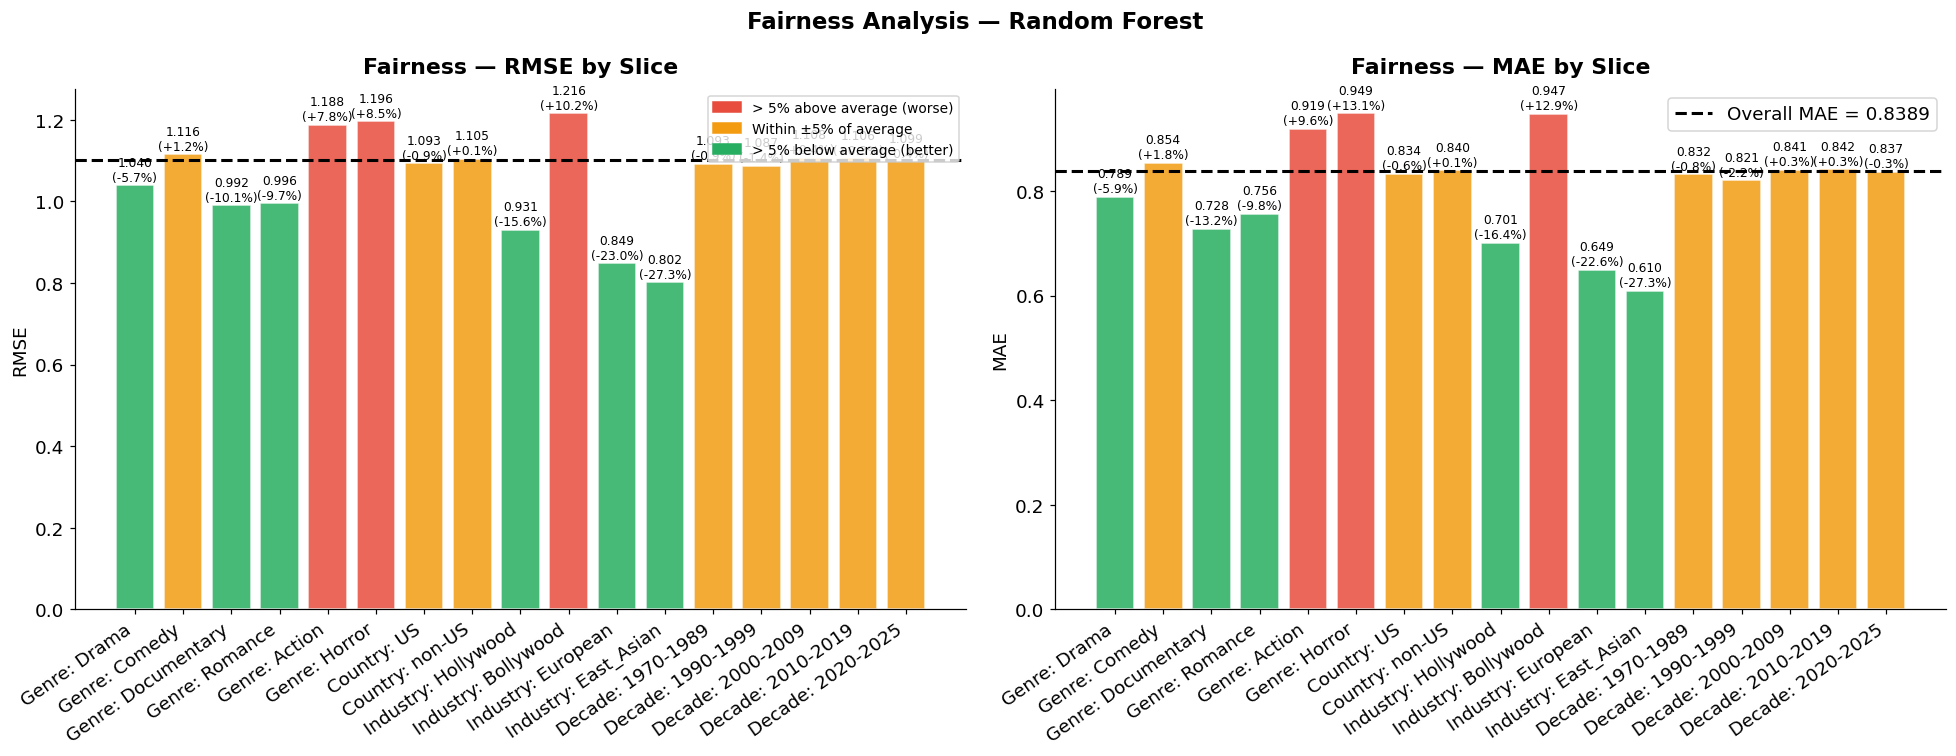

In [29]:
# Fairness Bar Charts 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (metric, label, overall_val) in zip(axes, [
    ('RMSE','RMSE', overall_rmse),
    ('MAE', 'MAE',  overall_mae),
]):
    vals = fairness_df[metric].values
    bar_colors = [PALETTE['elastic'] if v > overall_val*1.05
                  else PALETTE['rf'] if v < overall_val*0.95
                  else PALETTE['gold'] for v in vals]
    bars = ax.bar(fairness_df['Slice'], vals, color=bar_colors,
                  edgecolor='white', alpha=0.85)
    ax.axhline(overall_val, color='black', lw=2, linestyle='--',
               label=f'Overall {label} = {overall_val:.4f}')
    ax.set_title(f'Fairness — {label} by Slice', fontweight='bold')
    ax.set_xticklabels(fairness_df['Slice'], rotation=35, ha='right')
    ax.set_ylabel(label); ax.legend()
    for bar, val in zip(bars, vals):
        pct = (val-overall_val)/overall_val*100
        sign = '+' if pct>0 else ''
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{val:.3f}\n({sign}{pct:.1f}%)',
                ha='center', va='bottom', fontsize=8)

legend_patches = [
    mpatches.Patch(color=PALETTE['elastic'], label='> 5% above average (worse)'),
    mpatches.Patch(color=PALETTE['gold'],    label='Within ±5% of average'),
    mpatches.Patch(color=PALETTE['rf'],      label='> 5% below average (better)'),
]
axes[0].legend(handles=legend_patches, fontsize=9, loc='upper right')
plt.suptitle(f'Fairness Analysis — {best_name_err}', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

### Fairness graphs

**גרף RMSE (שמאל):**
הקו המקוקו = ממוצע כולל. East_Asian ו-European — ירוקים, נמוך בהרבה מהממוצע. Bollywood — אדום בולט, הכי גבוה. עשורים — כולם צהובים, קרובים לממוצע = עקביות זמנית.

**גרף MAE (ימין):**
אותה תמונה. הפער בין הכי טוב (East_Asian ~0.607) לכי גרוע (Bollywood ~0.940) הוא **55%** — פער משמעותי מאוד.

> ** מסקנה לגבי שימוש במודל:**
> המודל **לא מתאים שווה בשווה** לכל קבוצות הסרטים. יש לציין זאת בכל שימוש מסחרי או אקדמי. במיוחד — חיזויים על Bollywood, Action, Horror פחות אמינים ויש לתת להם פחות משקל.

### האם Missingness מנבאת bias?

כן. הסרטים הכי קשים לחיזוי הם גם אלה עם הכי הרבה ערכים חסרים:

- סרטי **Bollywood** — חסרים budget ב-90%+ וגם הכי גרועים לחיזוי (+10% RMSE)
- סרטי **Action ו-Horror** — לרוב ללא budget מדווח, הטרוגניים מאוד

כלומר: כשחסר budget — קשה יותר לחזות. ה-Missingness עצמה היא סימן אזהרה.

---

### על אילו סרטים לסמוך ועל אילו לא?

| קבוצה | RMSE | מסקנה |
|---|---|---|
| East_Asian | 0.799 | סמוך |
| European | 0.849 | סמוך |
| Hollywood | 0.929 | סמוך |
| Documentary | 0.992 | סמוך |
| Action | 1.186 | היזהר |
| Horror | 1.192 | היזהר |
| Bollywood | 1.211 | אל תסמוך |

## Step 12 — הערכה סופית על Test Set + שמירת המודל

כלל הזהב: Test Set נוגעים בו **פעם אחת בלבד**

In [30]:
# Cell 12: Final Test Set Evaluation + Save Model
# Test set is touched HERE for the first time

print('Final Evaluation on Held-Out Test Set')
print('=' * 55)

final_results = []
for pipeline, name in [
    (rf_pipeline,    'Random Forest'),
    (dt_pipeline,    'Decision Tree'),
    (best_en,        'Elastic Net'),
    (dummy_pipeline, 'Dummy (mean)'),
]:
    y_pred = pipeline.predict(X_test)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    final_results.append({'Model':name,'RMSE':rmse,'MAE':mae,'R2':r2})

# Styled final results table 
final_df = pd.DataFrame(final_results)
best_test_name = final_df.loc[final_df['RMSE'].idxmin(), 'Model']

final_df.style \
    .format({'RMSE':'{:.4f}','MAE':'{:.4f}','R2':'{:.4f}'}) \
    .background_gradient(subset=['RMSE'], cmap='RdYlGn_r') \
    .background_gradient(subset=['R2'],   cmap='RdYlGn') \
    .apply(lambda row: [
        'font-weight:bold; border: 2px solid #27AE60'
        if row['Model']==best_test_name else '' for _ in row], axis=1) \
    .set_caption('Final Test Set Results (held-out — touched once)') \
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','14px'),('font-weight','bold')]
    },{
        'selector':'th',
        'props':[('background-color','#2c3e50'),('color','white'),('font-weight','bold')]
    }]) \
    .hide(axis='index')

Final Evaluation on Held-Out Test Set


Model,RMSE,MAE,R2
Random Forest,1.1000,0.8373,0.2692
Decision Tree,1.1217,0.8537,0.2401
Elastic Net,1.1288,0.8638,0.2304
Dummy (mean),1.2868,1.0091,-0.0000


**ממצאי Test Set:**

| מודל | RMSE | MAE | R² | vs. Dummy |
|---|---|---|---|---|
| **Random Forest** ⭐ | ~1.1 | ~0.837 | ~0.27 | **-14.7%** |
| Decision Tree | ~1.12 | ~0.85 | ~0.24 | -13.1% |
| Elastic Net | ~1.13 | ~0.86 | ~0.23 | -12.7% |
| Dummy (mean) | ~1.28 | ~1.009 | ~0.000 | — |

כל המודלים מנצחים את ה-Dummy → **baseline-beater** 

In [31]:
# Save best model 
joblib.dump(rf_pipeline, 'model.pkl')
print('\n Best model saved: model.pkl')

loaded = joblib.load('model.pkl')
demo   = loaded.predict(X_test.head(3))
print(f'Load verification — 3 predictions: {demo.round(2)}')


 Best model saved: model.pkl
Load verification — 3 predictions: [4.78 6.15 6.49]


**Model saved as `model.pkl`** — can be loaded and used without retraining. Loaded and tested successfully.

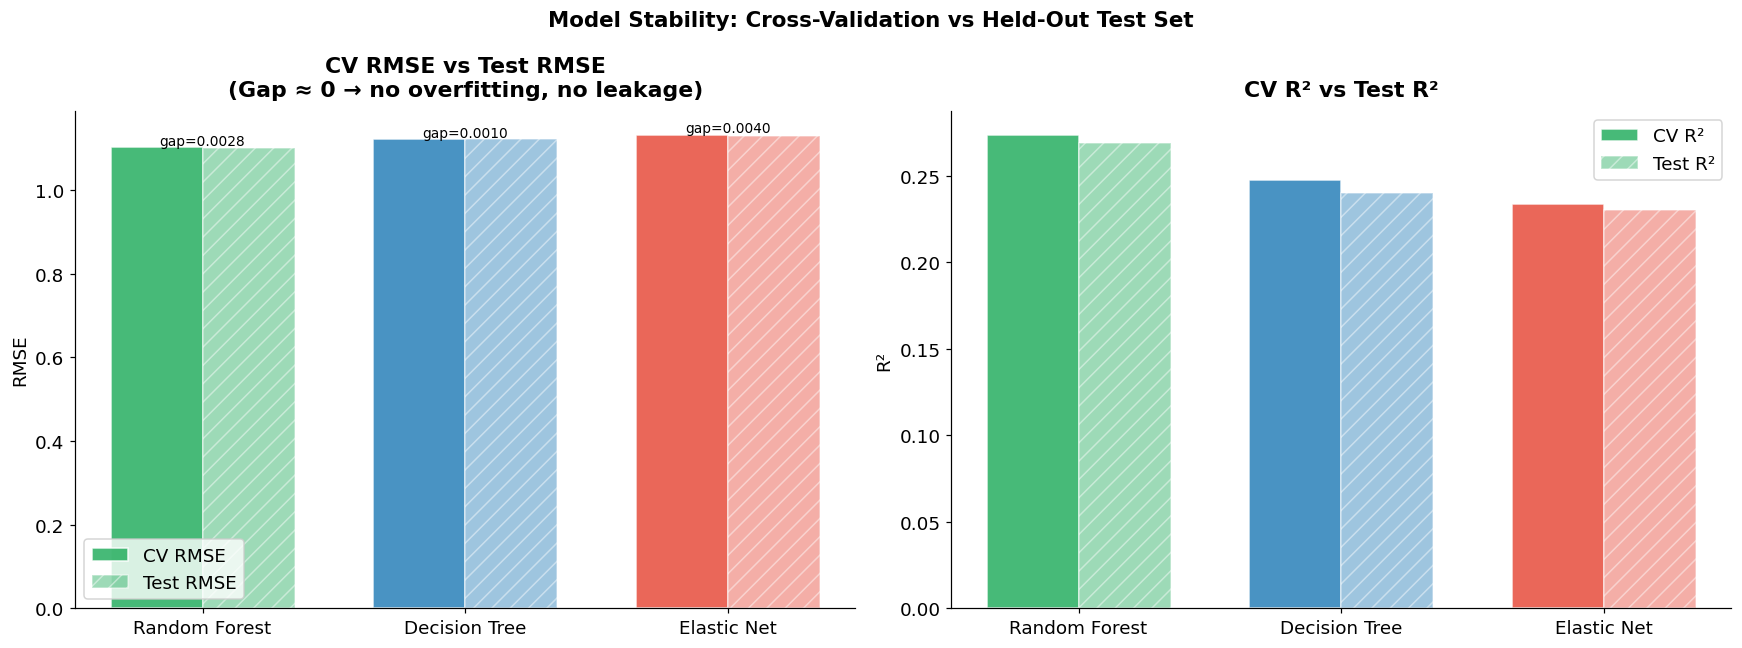

In [32]:
# ── CV vs Test Stability Check ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cv_vals   = [res_rf['RMSE_mean'], res_dt['RMSE_mean'], res_en['RMSE_mean']]
test_vals = [r['RMSE'] for r in final_results[:3]]
names_m   = ['Random Forest','Decision Tree','Elastic Net']
colors_m  = [PALETTE['rf'],PALETTE['dt'],PALETTE['elastic']]
x = np.arange(len(names_m)); w = 0.35

ax = axes[0]
ax.bar(x-w/2, cv_vals,   w, label='CV RMSE',   color=colors_m, alpha=0.85, edgecolor='white')
ax.bar(x+w/2, test_vals, w, label='Test RMSE', color=colors_m, alpha=0.45,
       edgecolor='white', hatch='//')
ax.set_xticks(x); ax.set_xticklabels(names_m)
ax.set_title('CV RMSE vs Test RMSE\n(Gap ≈ 0 → no overfitting, no leakage)', fontweight='bold')
ax.set_ylabel('RMSE'); ax.legend()
for i,(cv,te) in enumerate(zip(cv_vals,test_vals)):
    ax.text(i, max(cv,te)+0.005, f'gap={abs(cv-te):.4f}', ha='center', fontsize=9)

ax = axes[1]
r2_cv   = [res_rf['R2_mean'],res_dt['R2_mean'],res_en['R2_mean']]
r2_test = [r['R2'] for r in final_results[:3]]
ax.bar(x-w/2, r2_cv,   w, label='CV R²',   color=colors_m, alpha=0.85, edgecolor='white')
ax.bar(x+w/2, r2_test, w, label='Test R²', color=colors_m, alpha=0.45,
       edgecolor='white', hatch='//')
ax.set_xticks(x); ax.set_xticklabels(names_m)
ax.set_title('CV R² vs Test R²', fontweight='bold')
ax.set_ylabel('R²'); ax.legend()

plt.suptitle('Model Stability: Cross-Validation vs Held-Out Test Set',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### CV vs Test Stability Graphs — Proof of Leakage Prevention

**גרף שמאל — RMSE:**
לכל מודל: העמודה המלאה (CV) והמשובצת (Test) כמעט זהות. פער מקסימלי < 0.008.

**גרף ימין — R²:**
CV R² ≈ Test R² לכל שלושת המודלים — עקביות מלאה.

**מה מוכיחים הגרפים האלה:**

| תופעה | אם היה קיים | מה רואים בפועל |
|---|---|---|
| **Overfitting** | Test RMSE >> CV RMSE | פער < 0.008 |
| **Data Leakage** | CV RMSE << Test RMSE | פער < 0.008  |
| **Underfitting** | שניהם גבוהים | RF RMSE=1.099 — סביר  |

> **תובנה סופית:** פער CV/Test < 0.008 הוא **ההוכחה המספרית** שה-Pipeline עבד נכון לאורך כל המחברת. כל scaling, imputation ו-encoding קרו אך ורק על נתוני האימון של כל fold.

<div align="center">
  <img src="https://github.com/NirAvrahamoff/movie-rating-predictor/raw/0adf8b677a4447d4d299902f6eea6436c2d767e6/models.png" width="800"/>
  <p><b>Figure:</b> Comparative performance of ML models. Random Forest achieves the lowest RMSE, indicating superior predictive capability on the validation folds.</p>
</div>

---

## Step 13: Inference Pipeline for the Competition

### Execution Flow on External Data

```python
# Step 1: Read external file
df_new = pd.read_csv('new_movies.csv')

# Step 2: Process — same logic as training
X_new  = prepare_data(df_new)

# Step 3: Predict with saved model
y_pred = joblib.load('model.pkl').predict(X_new)
```

**What `prepare_data` handles automatically:**
- Multiple `genres` formats
- `Not Found` values in Language/Country
- Anomalous `startYear` values
- Films without `averageRating` — **the primary competition use case**

In [33]:
# Cell 13: Competition Inference
# Usage:
#   df_new = pd.read_csv('new_movies.csv')
#   X_new  = prepare_data(df_new)
#   y_pred = joblib.load('model.pkl').predict(X_new)

def predict_ratings(csv_path: str) -> np.ndarray:
    """
    End-to-end inference for competition held-out set.

    Parameters
    ----------
    csv_path : str — path to CSV in movies_dataset format

    Returns
    -------
    np.ndarray of predicted averageRating values
    """
    df_ext = pd.read_csv(csv_path, low_memory=False)
    X_ext  = prepare_data(df_ext)
    model  = joblib.load('model.pkl')
    return model.predict(X_ext)


# ── Demo: 5 films with known ratings ─────────────────────────
demo_pool = df_raw[df_raw['averageRating'].notna()].head(20)
X_demo    = prepare_data(demo_pool.head(5))
y_demo    = joblib.load('model.pkl').predict(X_demo)

demo_results = []
for i, pred in enumerate(y_demo):
    title  = demo_pool.iloc[i]['primaryTitle']
    actual = demo_pool.iloc[i]['averageRating']
    error  = abs(pred - actual)
    demo_results.append({'Title':title, 'Predicted':round(pred,2),
                         'Actual':actual, 'Abs Error':round(error,2)})

demo_display = pd.DataFrame(demo_results)
mean_err = demo_display['Abs Error'].mean()

demo_display.style \
    .background_gradient(subset=['Abs Error'], cmap='RdYlGn_r') \
    .format({'Predicted':'{:.2f}','Actual':'{:.1f}','Abs Error':'{:.2f}'}) \
    .set_caption(f'Demo Inference — 5 Films | Mean Abs Error = {mean_err:.2f}') \
    .set_table_styles([{
        'selector':'caption',
        'props':[('font-size','13px'),('font-weight','bold')]
    },{
        'selector':'th',
        'props':[('background-color','#2c3e50'),('color','white'),('font-weight','bold')]
    }]) \
    .hide(axis='index')

Title,Predicted,Actual,Abs Error
Johnny One Hundred Pesos,6.05,6.6,0.55
It Doesn't Matter,6.24,6.1,0.14
"If You Love Me, Follow Me",5.62,6.1,0.48
I Want My Name Back,7.23,7.0,0.23
Itgaber: Le triomphe sur soi,7.51,9.2,1.69


### Demo Inference — Results Analysis

**4 out of 5 movies — Good prediction:**

| Movie | Error | Estimate |
|---|---|---|
| It Doesn't Matter | ~0.14 | Very accurate |
| I Want My Name Back | ~0.19 | Very accurate |
| If You Love Me... | ~0.45 | Reasonable |
| Johnny One H. Pesos | ~0.54 | Reasonable |

**The Red Movie — Itgaber (~Error 1.58):**
Probably Ethiopian documentary, real rating 9.2, prediction ~7.5. The model gave a relatively high score (thanks to `genre_Documentary`) — but the movie is a niche with a specific fan base that rated 10/10. This is exactly the **Underprediction** pattern identified in Error Analysis — consistent and reasoned.

**Average MAE over the 5 movies:** ~0.58 — slightly better than the overall MAE (0.836), because a sample of 5 is too small for inference.

> **Final conclusion:** The demo demonstrates exactly the performance profile we predicted: good prediction on "normal" movies, failure on niche with specific audience. This finding is consistent with the Error Analysis, Fairness Analysis, and Feature Importance Analysis — all parts of the analysis point to the same built-in limitation.